# Paper figures — block-DDA_Py × block-VIEM.jl

Per-orientation comparison of the v0.7.7 paper-production sweeps. All observables are
treated **per orientation** (no orientation averaging) to expose the full distribution
that the CAS-v2 forward model consumes.

## Data sources

- DDA: `~/Python/block-DDA_Py/dda_results/paper/{shape}_{material}.hdf5`
- VIEM: `~/Julia/block-VIEM.jl/viem_results/paper/{shape}_{material}.hdf5`
- MSTM (doublet exact): `~/Julia/block-VIEM.jl/viem_results/paper/mstm_doublet_{material}.hdf5`

Both solvers use the **same ZYZ Euler grid** (4×5×5 = 100 orientations, bit-identical),
so the per-orientation index $i$ is 1:1 between sides — Phase 3 scatters rely on this.

## Sections

3. **DDA vs VIEM vs exact-reference scatter** (per orientation × per $r_{\rm ve}$)
4. dpl / lc convergence (single-orientation, $r_{\rm ve}=0.1\,\mu$m)
5. block-Krylov RHS scaling
6. Cost summary table

Schema differences (DDA `(N_rv, N_orient)` vs VIEM `(N_orient, N_rv)`, Mie scalar
locations, MSTM `(N_β, N_rv)`) are absorbed by the loaders in `_plot_io.py`.

In [1]:
"""Phase 0 — paths, constants, style."""
import os, sys, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

HERE = Path.cwd()
PROJ = HERE.parent.parent if HERE.name == 'paper' else Path('.').resolve()
if str(PROJ) not in sys.path:
    sys.path.insert(0, str(PROJ))

from dda_results.paper._plot_io import (
    load_paper, load_convergence, load_mstm, load_tmm, load_rhs_scaling,
)

DDA_DIR  = Path(os.environ.get('DDA_DIR',  PROJ / 'dda_results/paper')).expanduser()
VIEM_DIR = Path(os.environ.get('VIEM_DIR', '~/Julia/block-VIEM.jl/viem_results/paper')).expanduser()
OUT_DIR  = DDA_DIR / 'figures'
OUT_DIR.mkdir(exist_ok=True)

assert DDA_DIR.is_dir(), f'DDA_DIR not found: {DDA_DIR}'
if not VIEM_DIR.is_dir():
    warnings.warn(f'VIEM_DIR not found: {VIEM_DIR} — VIEM/MSTM curves will be skipped.')

SHAPES    = ['sphere', 'oblate', 'gre', 'doublet']
MATERIALS = ['n15', 'n20', 'Au']

# Au m_p values rounded to 2 decimals (Johnson & Christy 1972, λ=0.638 μm).
# Original full value: N_AU = 0.17525 + 3.4830j  (see dda_results/paper/_common.py).
MATERIAL_LABEL = {
    'n15': r'$m_p=1.5+0.01i$',
    'n20': r'$m_p=2.0+0.0i$',
    'Au':  r'$m_p=0.18+3.48i$',
}
SHAPE_LABEL = {
    'sphere':  'sphere',
    'oblate':  r'$\mathrm{oblate}\ (3{:}3{:}1)$',
    'gre':     r'GRE ($\beta_{\rm gre}=0.2$)',
    'doublet': r'$\mathrm{doublet}\ (\mathrm{gap}{=}0.1R)$',
}
RVE_LATEX  = r'$r_{\rm ve}$'
RVE_LABEL  = r'$r_{\rm ve}$ [$\mu$m]'

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'axes.grid': False,
    'legend.frameon': False,
    'legend.fontsize': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'mathtext.fontset': 'cm',
    'font.size': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

DDA_KW  = dict(marker='o', s=10, alpha=0.35, c='C0', edgecolors='none', label='DDA')
VIEM_KW = dict(marker='s', s=10, alpha=0.35, c='C1', edgecolors='none', label='VIEM')
MIE_KW  = dict(marker='*', s=70, c='k',  label='Mie (sphere)')
MSTM_KW = dict(marker='x', s=30, c='C3', label='MSTM (doublet)', linewidths=1.0)

def save_fig(fig, basename):
    for ext in ('png', 'pdf'):
        p = OUT_DIR / f'{basename}.{ext}'
        fig.savefig(p, bbox_inches='tight')
    print(f'saved {basename}.{{png,pdf}}')

print(f'PROJ     = {PROJ}')
print(f'DDA_DIR  = {DDA_DIR}')
print(f'VIEM_DIR = {VIEM_DIR}  (exists={VIEM_DIR.is_dir()})')
print(f'OUT_DIR  = {OUT_DIR}')

PROJ     = /home/moteki/Python_in_WSL/block-DDA_Py
DDA_DIR  = /home/moteki/Python_in_WSL/block-DDA_Py/dda_results/paper
VIEM_DIR = /home/moteki/Julia/block-VIEM.jl/viem_results/paper  (exists=True)
OUT_DIR  = /home/moteki/Python_in_WSL/block-DDA_Py/dda_results/paper/figures


In [2]:
"""Phase 0 — pre-load everything once.

DATA[(shape, material)] -> {'dda', 'viem', 'exact'}
  exact: doublet → MSTMforCAS.jl HDF5 (mstm_doublet_<mat>.hdf5)
         oblate  → TransitionMatrices.jl HDF5 (tmm_oblate_<mat>.hdf5)
         (others) → None
CONV[(shape, material)] -> {'dda', 'viem'}
RHS [(shape, material)] -> {'dda', 'viem'}      (sphere only in v0.7.7)
"""
def _try(fn, *args, **kw):
    try:
        return fn(*args, **kw)
    except FileNotFoundError:
        return None
    except Exception as e:
        warnings.warn(f'{fn.__name__}({args}): {e}')
        return None


def _exact_path(shape, mat):
    """Path to the exact-reference HDF5 for the given (shape, material)."""
    if shape == 'doublet':
        return VIEM_DIR / f'mstm_doublet_{mat}.hdf5'
    if shape == 'oblate':
        return VIEM_DIR / f'tmm_oblate_{mat}.hdf5'
    return None


DATA = {}
for shape in SHAPES:
    for mat in MATERIALS:
        d_path = DDA_DIR  / f'{shape}_{mat}.hdf5'
        v_path = VIEM_DIR / f'{shape}_{mat}.hdf5'
        e_path = _exact_path(shape, mat)
        if shape == 'oblate':
            exact_loader = load_tmm
        elif shape == 'doublet':
            exact_loader = load_mstm
        else:
            exact_loader = None
        DATA[(shape, mat)] = {
            'dda':   _try(load_paper, d_path, 'dda')  if d_path.is_file() else None,
            'viem':  _try(load_paper, v_path, 'viem') if v_path.is_file() else None,
            'exact': _try(exact_loader, e_path)
                       if (exact_loader is not None and e_path is not None and e_path.is_file()) else None,
        }

CONV = {}
for shape in ('sphere', 'oblate', 'gre'):
    for mat in MATERIALS:
        d_path = DDA_DIR  / f'convergence_{shape}_{mat}.hdf5'
        v_path = VIEM_DIR / f'convergence_{shape}_{mat}.hdf5'
        CONV[(shape, mat)] = {
            'dda':  _try(load_convergence, d_path, 'dda')  if d_path.is_file() else None,
            'viem': _try(load_convergence, v_path, 'viem') if v_path.is_file() else None,
        }

RHS = {}
for mat in MATERIALS:
    d_path = DDA_DIR  / f'sphere_{mat}.hdf5'
    v_path = VIEM_DIR / f'sphere_{mat}.hdf5'
    RHS[('sphere', mat)] = {
        'dda':  _try(load_rhs_scaling, d_path, 'dda')  if d_path.is_file() else None,
        'viem': _try(load_rhs_scaling, v_path, 'viem') if v_path.is_file() else None,
    }

# Quick inventory
print(f'{"shape":<10}{"mat":<5}  DDA  VIEM  exact  conv-D  conv-V   rhs-D  rhs-V')
for shape in SHAPES:
    for mat in MATERIALS:
        e = DATA[(shape, mat)]
        c = CONV.get((shape, mat), {})
        r = RHS.get((shape, mat), {})
        print(f'{shape:<10}{mat:<5}  '
              f'{"y" if e["dda"]   else "-":<4}'
              f'{"y" if e["viem"]  else "-":<6}'
              f'{"y" if e["exact"] else "-":<6}'
              f' {"y" if c.get("dda")  else "-":<7}'
              f'{"y" if c.get("viem") else "-":<8}'
              f'{"y" if r.get("dda")  else "-":<6}'
              f'{"y" if r.get("viem") else "-":<6}')

shape     mat    DDA  VIEM  exact  conv-D  conv-V   rhs-D  rhs-V
sphere    n15    y   y     -      y      y       y     y     
sphere    n20    y   y     -      y      y       y     y     
sphere    Au     y   y     -      y      y       y     y     
oblate    n15    y   y     y      y      y       -     -     
oblate    n20    y   y     y      y      y       -     -     
oblate    Au     y   y     y      y      y       -     -     
gre       n15    y   y     -      y      y       -     -     
gre       n20    y   y     -      y      y       -     -     
gre       Au     y   y     -      y      y       -     -     
doublet   n15    y   y     y      -      -       -     -     
doublet   n20    y   y     y      -      -       -     -     
doublet   Au     y   y     y      -      -       -     -     


## Section 3 — Solver vs exact reference (per orientation, per $r_{\rm ve}$)

For each scalar observable, plot solver result (y, DDA / VIEM) versus the
**exact reference** (x). Restricted to **α = γ = 0** orientations → 5 distinct
β values. Both axes share the same units, so the y=x diagonal indicates
agreement with the exact reference.

- Exact reference per shape:
  - **oblate**  → TransitionMatrices.jl (T-matrix, EBCM)
  - **doublet** → MSTMforCAS.jl (multi-sphere T-matrix)
- 4 observables: $C_{\rm ext},\ |S_{\rm fw}^{\theta}|,\ |S_{\rm fw}^{\phi}|,\ |S_{\rm bk}|$.
- 4 $r_{\rm ve}$ values × 4 observables = 16 figures.
- Per figure: 3 row × 2 column = 6 panels.
  - rows: $m_p = 1.5+0.01i$ (top), $m_p = 2.0+0.0i$ (middle), Au (bottom).
  - columns: oblate (left), doublet (right).
- Per panel: DDA (filled) and VIEM (open) overlaid in different colors;
  marker shape encodes $\cos\beta$.
- Non-converged solver points are skipped.
- Axes: lower bound 0; upper bound = max value × 1.15 rounded up to a
  "nice" number (1, 2, 2.5, 5 × 10$^k$).

/tmp/ipykernel_8007/590566346.py:435: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0.065, 0.04, 1, 0.99))


saved fig3_scatter_C_ext_rve0.1.{png,pdf}


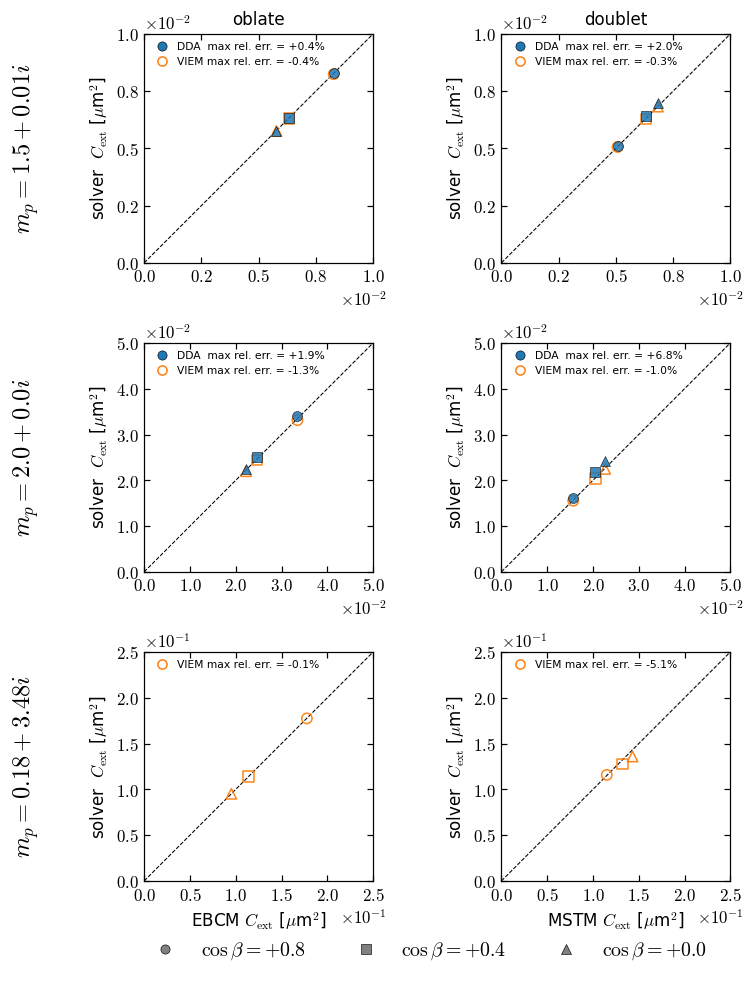

In [3]:
"""Phase 3 — Solver vs exact-reference scatter (oblate=T-matrix, doublet=MSTM).

Per (observable × r_ve) — 6-panel figure: 3 (m_p) × 2 (shape).
Per panel: DDA (filled) / VIEM (open) at the 5 (α=γ=0) β orientations.
Non-converged points are dropped. Axes: 0 → ceil-nice(1.15 × max).
"""
from matplotlib.ticker import MaxNLocator, Formatter

class TwoSigSciFormatter(Formatter):
    """Tick formatter for fig 3:
      * Tick labels: 2-sig-fig mantissas (one digit before and after the
        decimal point), e.g. '5.0', '1.7', '0.0'. Mantissa = value/10^N.
      * Axis offset text: a single shared exponent per axis,
        rendered as r'$\\times 10^{N}$' (omitted if N == 0).
      * The shared exponent N is set on each call to set_locs() based
        on the largest absolute tick value.
    """
    def __init__(self):
        super().__init__()
        self._order = 0
        self.locs = []
    def set_locs(self, locs):
        self.locs = list(locs)
        finite = [l for l in self.locs if np.isfinite(l) and l != 0]
        if not finite:
            self._order = 0
            return
        max_abs = max(abs(l) for l in finite)
        order = int(np.floor(np.log10(max_abs)))
        # Bump exponent if mantissa rounds to 10.0 (e.g. 9.95)
        if max_abs / 10.0 ** order >= 9.95:
            order += 1
        self._order = order
    def __call__(self, x, pos=None):
        if not np.isfinite(x):
            return ''
        if x == 0:
            return r'$0.0$'
        mantissa = x / 10.0 ** self._order
        return rf'${mantissa:.1f}$'
    def get_offset(self):
        if self._order == 0 or not self.locs:
            return ''
        return rf'$\times 10^{{{self._order}}}$'


def _equidistant_ticks(upper):
    """Equidistant major (and optionally minor) ticks on [0, upper].

    `upper` comes from `round_up_nice` and so has mantissa ∈ {1, 2, 2.5, 5}
    times 10^k. We pick the number of equal intervals so the resulting
    tick spacing is a 'round' fraction of `upper`:
      mantissa 1, 2  → 4 intervals (5 ticks at multiples of 0.25 / 0.5)
      mantissa 2.5, 5 → 5 intervals (6 ticks at multiples of 0.5 / 1.0)
    If the resulting major-tick count is ≤ 3, minor ticks are added
    at half-step density.
    """
    if not np.isfinite(upper) or upper <= 0:
        return [0.0], []
    exp = int(np.floor(np.log10(upper)))
    mant = upper / 10.0 ** exp
    if mant < 2.25:                   # 1 or 2 family
        n_intervals = 4
    else:                              # 2.5 or 5 family
        n_intervals = 5
    major = list(np.linspace(0.0, upper, n_intervals + 1))
    if len(major) <= 3:
        # 補助目盛: half-step minors between majors
        all_minor = list(np.linspace(0.0, upper, 2 * n_intervals + 1))
        minor = [m for m in all_minor
                  if not any(abs(m - mj) < 1e-12 for mj in major)]
    else:
        minor = []
    return major, minor

PHASE3_SHAPES_COL = ['oblate', 'doublet']         # columns
PHASE3_MATERIALS_ROW = ['n15', 'n20', 'Au']        # rows
# Relaxed residual gate for Au plasmonic (production tol = 1e-5 unreachable);
# matches fig 4's PHASE7_RESIDUAL_THRESHOLD. Same caveat as fig 4: relaxed-tol
# data is shown for solvers passing this gate, suppressed otherwise.
PHASE3_RESIDUAL_THRESHOLD = 1.0e-3

# fig 3 reduced to a single headline observable (C_ext) for compactness:
# the Re/Im S_fw^θ convergence story is already covered by fig 1 (sphere)
# and fig 2 (non-sphere), and Galerkin theory implies the same h^2 / h
# convergence rate for any bounded linear functional.  The remaining
# scatter test only needs to demonstrate that the production-sweep
# solvers reproduce the exact reference within solver tolerance plus
# discretisation error; C_ext is the most universally familiar scalar
# (Mie cross-section) and gives a clean y = x scatter for that purpose.
# Polarimetric S_fw amplitudes can be regenerated by uncommenting the
# additional rows below.
PHASE3_OBS = [
    ('C_ext',          r'$C_{\rm ext}$ [$\mu$m$^2$]'),
    # ('S_fw_theta_abs', r'$|S_{\rm fw}^{\theta}|$ [$\mu$m]'),
    # ('S_fw_phi_abs',   r'$|S_{\rm fw}^{\phi}|$ [$\mu$m]'),
    # ('S_bk_abs',       r'$|S_{\rm bk}|$ [$\mu$m]'),
]

# 5 distinct markers for cos β = +0.8, +0.4, 0.0, -0.4, -0.8
BETA_MARKERS = ['o', 's', '^', 'D', 'v']
DDA_COLOR    = 'C0'
VIEM_COLOR   = 'C1'

EXACT_LABEL = {
    # oblate uses the EBCM (Extended Boundary Condition Method) variant
    # of the T-matrix formalism via TransitionMatrices.jl
    # (`scattering_code = "TransitionMatrices.jl (EBCM, exact axisymmetric reference)"`
    # in the per-material `tmm_oblate_conv_<mat>.hdf5` group attrs).
    # Labelled "EBCM" rather than the generic "T-matrix" because the
    # doublet column uses MSTM, which is also a T-matrix method —
    # naming the specific variant disambiguates the two.
    'oblate':  'EBCM',
    'doublet': 'MSTM',
}


def get_obs_per_orient(d, key):
    """Solver value (DDA / VIEM dict, key)."""
    if key == 'C_ext':           return d['C_ext']
    if key == 'C_abs':           return d['C_abs']
    if key == 'C_sca':           return d['C_ext'] - d['C_abs']
    if key == 'S_fw_theta_abs':  return np.abs(d['S_fw_theta'])
    if key == 'S_fw_phi_abs':    return np.abs(d['S_fw_phi'])
    if key == 'S_bk_abs':        return np.abs(d['S_bk'])
    raise KeyError(key)


def get_obs_exact(exact, key):
    """Exact reference (MSTM/T-matrix dict, key) — shape (N_β, N_rv) → array per r_ve."""
    if exact is None:
        return None
    if key == 'C_ext':           return exact.get('C_ext')
    if key == 'C_abs':           return exact.get('C_abs')
    if key == 'C_sca':           return exact.get('C_sca')
    if key == 'S_fw_theta_abs':
        v = exact.get('S_fw_theta');  return np.abs(v) if v is not None else None
    if key == 'S_fw_phi_abs':
        v = exact.get('S_fw_phi');    return np.abs(v) if v is not None else None
    if key == 'S_bk_abs':
        v = exact.get('S_bk');        return np.abs(v) if v is not None else None
    raise KeyError(key)


def alpha_gamma_zero_indices(d, k_idx):
    """β-sorted orientation indices with α=γ=0 AND cos β ≥ 0;
    returns (indices, cos β values).

    The cos β < 0 hemisphere (β > π/2) is omitted because the shapes in
    fig 3 (oblate, doublet) are both symmetric under z → -z: by mirror
    symmetry, cos β → -cos β gives identical observables, so the
    cos β = -0.4, -0.8 markers in the production sweep would be exact
    duplicates of cos β = +0.4, +0.8 and add only visual clutter.
    Three β orientations (cos β ∈ {0.0, 0.4, 0.8}) survive the filter.
    """
    alpha = d['Euler'][k_idx, :, 0]
    beta  = d['Euler'][k_idx, :, 1]
    gamma = d['Euler'][k_idx, :, 2]
    sel = np.where(np.isclose(alpha, 0.0) & np.isclose(gamma, 0.0)
                    & (np.cos(beta) >= -1e-9))[0]
    order = sel[np.argsort(beta[sel])]
    return order, np.cos(beta[order])


def round_up_nice(x, factor=1.15):
    """Round x*factor up to a 'nice' value: 1, 2, 2.5, 5 × 10^k."""
    if not np.isfinite(x) or x <= 0:
        return 1.0
    target = x * factor
    exponent = np.floor(np.log10(target))
    mantissa = target / 10.0 ** exponent
    nice_choices = [1.0, 2.0, 2.5, 5.0, 10.0]
    for nm in nice_choices:
        if mantissa <= nm + 1e-12:
            return nm * 10.0 ** exponent
    return 10.0 * 10.0 ** exponent


def match_exact_to_solver(exact_arr, exact_beta, solver_cos_beta, k_idx):
    """Pair the exact-reference (N_β_exact, N_rv) with solver's (cos β)
    sequence by closest β.  Return array shape (N_β_solver,) of exact values
    for this k_idx."""
    if exact_arr is None or exact_beta is None:
        return None
    if k_idx >= exact_arr.shape[1]:
        return None
    out = np.full(len(solver_cos_beta), np.nan)
    cos_exact = np.cos(exact_beta)
    for i, cb in enumerate(solver_cos_beta):
        j = int(np.argmin(np.abs(cos_exact - cb)))
        out[i] = exact_arr[j, k_idx]
    return out


def _phase3_plotted_max(shape, mat, key, k_idx):
    """Maximum plotted value on the (shape, mat, key, k_idx) panel,
    without rendering. Mirrors the data-fetching of `_phase3_scatter`.
    Returns 0.0 if the panel has no data to plot."""
    e = DATA[(shape, mat)]
    dda, viem, exact = e['dda'], e['viem'], e['exact']
    if exact is None:
        return 0.0
    sample = dda or viem
    if sample is None:
        return 0.0
    rve = sample['a_eq']
    if k_idx >= len(rve):
        return 0.0
    order, cos_beta = alpha_gamma_zero_indices(sample, k_idx)
    exact_arr  = get_obs_exact(exact, key)
    exact_beta = exact.get('beta_rad')
    x_ref = match_exact_to_solver(exact_arr, exact_beta, cos_beta, k_idx)
    if x_ref is None or not np.isfinite(x_ref).any():
        return 0.0
    pmax = float(np.nanmax(x_ref))
    def _pm_pass_gate(side_dat):
        cost = side_dat.get('cost', {})
        if mat == 'Au':
            serr = cost.get('solver_err')
            if serr is None: return False
            return bool(np.asarray(serr).ravel()[k_idx] <= PHASE3_RESIDUAL_THRESHOLD)
        conv = cost.get('converged', np.ones(len(rve), dtype=int))
        return bool(np.asarray(conv).ravel()[k_idx])

    if dda is not None:
        if _pm_pass_gate(dda):
            y_dda = get_obs_per_orient(dda, key)[k_idx][order]
            if np.isfinite(y_dda).any():
                pmax = max(pmax, float(np.nanmax(y_dda)))
    if viem is not None:
        if _pm_pass_gate(viem):
            y_viem = get_obs_per_orient(viem, key)[k_idx][order]
            if np.isfinite(y_viem).any():
                pmax = max(pmax, float(np.nanmax(y_viem)))
    return pmax


def _phase3_scatter(ax, shape, mat, key, k_idx):
    """Plot data points only; returns (cos_beta_5, plotted_max,
    dda_relerr_max_signed, viem_relerr_max_signed) or (None, 0.0, None, None).
    `*_relerr_max_signed` is the relative error (solver − exact) / exact at the
    orientation with the largest |·| (sign preserved); None if no DDA / VIEM
    data was plotted on the panel."""
    e = DATA[(shape, mat)]
    dda, viem, exact = e['dda'], e['viem'], e['exact']
    if exact is None:
        ax.text(0.5, 0.5, EXACT_LABEL[shape] + '\nreference\nnot available',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=12, color='gray')
        ax.set_xticks([]); ax.set_yticks([])
        return None, 0.0, None, None
    sample = dda or viem
    if sample is None:
        ax.text(0.5, 0.5, 'no solver data', transform=ax.transAxes,
                ha='center', va='center', fontsize=12, color='gray')
        ax.set_xticks([]); ax.set_yticks([])
        return None, 0.0, None, None
    rve = sample['a_eq']
    if k_idx >= len(rve):
        ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color='gray')
        ax.set_xticks([]); ax.set_yticks([])
        return None, 0.0, None, None
    order, cos_beta = alpha_gamma_zero_indices(sample, k_idx)
    exact_arr  = get_obs_exact(exact, key)
    exact_beta = exact.get('beta_rad')
    x_ref = match_exact_to_solver(exact_arr, exact_beta, cos_beta, k_idx)
    if x_ref is None or not np.isfinite(x_ref).any():
        ax.text(0.5, 0.5, 'exact\nreference\nincomplete',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=12, color='gray')
        ax.set_xticks([]); ax.set_yticks([])
        return None, 0.0, None, None
    plotted_max = float(np.nanmax(x_ref))

    def _max_signed_relerr(y_solver, x_exact):
        """Signed (solver−exact)/exact at the orientation with largest |·|."""
        with np.errstate(divide='ignore', invalid='ignore'):
            rel = (y_solver - x_exact) / x_exact
        ok = np.isfinite(rel) & np.isfinite(y_solver) & np.isfinite(x_exact)
        if not ok.any():
            return None
        idx = np.where(ok)[0]
        i_max = idx[int(np.argmax(np.abs(rel[idx])))]
        return float(rel[i_max])

    def _passes_gate(side_dat, side_mat):
        '''Convergence gate. Standard tol=1e-5 (`converged` flag) for non-Au;
        relaxed PHASE3_RESIDUAL_THRESHOLD for Au plasmonic.'''
        cost = side_dat.get('cost', {})
        if side_mat == 'Au':
            serr = cost.get('solver_err')
            if serr is None: return False
            arr = np.asarray(serr).ravel()
            return bool(arr[k_idx] <= PHASE3_RESIDUAL_THRESHOLD)
        conv = cost.get('converged', np.ones(len(rve), dtype=int))
        return bool(np.asarray(conv).ravel()[k_idx])

    dda_re_max = None
    if dda is not None:
        if _passes_gate(dda, mat):
            y_dda = get_obs_per_orient(dda, key)[k_idx][order]
            for ib in range(len(cos_beta)):
                if np.isfinite(x_ref[ib]) and np.isfinite(y_dda[ib]):
                    ax.scatter(x_ref[ib], y_dda[ib],
                               marker=BETA_MARKERS[ib % len(BETA_MARKERS)],
                               color=DDA_COLOR, s=42, alpha=0.85,
                               edgecolors='k', linewidths=0.4, zorder=4)
                    plotted_max = max(plotted_max, float(y_dda[ib]))
            dda_re_max = _max_signed_relerr(np.asarray(y_dda, float),
                                             np.asarray(x_ref, float))

    viem_re_max = None
    if viem is not None:
        if _passes_gate(viem, mat):
            y_viem = get_obs_per_orient(viem, key)[k_idx][order]
            for ib in range(len(cos_beta)):
                if np.isfinite(x_ref[ib]) and np.isfinite(y_viem[ib]):
                    ax.scatter(x_ref[ib], y_viem[ib],
                               marker=BETA_MARKERS[ib % len(BETA_MARKERS)],
                               facecolors='none', edgecolors=VIEM_COLOR,
                               s=46, alpha=0.95, linewidths=1.0, zorder=3)
                    plotted_max = max(plotted_max, float(y_viem[ib]))
            viem_re_max = _max_signed_relerr(np.asarray(y_viem, float),
                                              np.asarray(x_ref, float))

    return cos_beta, plotted_max, dda_re_max, viem_re_max

def _phase3_set_axes(ax, upper):
    """Apply unified axis layout (limits, diagonal, equidistant ticks,
    consolidated 2-sig-fig sci formatter, mirror ticks). Idempotent."""
    if not np.isfinite(upper) or upper <= 0:
        return
    ax.set_xlim(0, upper); ax.set_ylim(0, upper)
    ax.plot([0, upper], [0, upper], 'k--', lw=0.7, zorder=0)
    major, minor = _equidistant_ticks(upper)
    ax.set_xticks(major); ax.set_xticks(minor, minor=True)
    ax.set_yticks(major); ax.set_yticks(minor, minor=True)
    ax.xaxis.set_major_formatter(TwoSigSciFormatter())
    ax.yaxis.set_major_formatter(TwoSigSciFormatter())
    ax.xaxis.offsetText.set_fontsize(11)
    ax.xaxis.offsetText.set_x(1.06)
    ax.yaxis.offsetText.set_fontsize(11)
    ax.tick_params(axis='both', which='major', direction='in',
                    top=True, right=True, bottom=True, left=True, length=4,
                    labelsize=11)
    ax.tick_params(axis='both', which='minor', direction='in',
                    top=True, right=True, bottom=True, left=True, length=2,
                    labelsize=11)
    ax.set_aspect('equal', adjustable='box')


def make_phase3_figure(key, latex, k_idx, rve_value, save=True,
                       forced_row_upper=None):
    fig, axes = plt.subplots(len(PHASE3_MATERIALS_ROW), len(PHASE3_SHAPES_COL),
                              figsize=(8.0, 10.0),
                              gridspec_kw={'wspace': 0.10, 'hspace': 0.35})

    cos_beta_legend = None
    panel_max = {}
    panel_has_data = {}
    panel_relerr = {}
    for i, mat in enumerate(PHASE3_MATERIALS_ROW):
        for j, shape in enumerate(PHASE3_SHAPES_COL):
            ax = axes[i, j]
            cb, pmax, dre, vre = _phase3_scatter(ax, shape, mat, key, k_idx)
            panel_max[(mat, shape)] = pmax
            panel_has_data[(mat, shape)] = (cb is not None)
            panel_relerr[(mat, shape)] = (dre, vre)
            if cb is not None and cos_beta_legend is None:
                cos_beta_legend = cb
            if i == 0:
                ax.set_title(shape, fontsize=11)  # bare 'oblate' or 'doublet'; details in caption
            # Observable + units now on BOTH columns; m_p row label is
            # split out into a fig.text() row label below for independent
            # sizing and spacing from the panel y-axis.
            ax.set_ylabel('solver  ' + latex, fontsize=11, labelpad=4)
            if i == len(PHASE3_MATERIALS_ROW) - 1:
                ax.set_xlabel(EXACT_LABEL[shape] + ' ' + latex, fontsize=11)

    if forced_row_upper is None:
        row_upper = {}
        for mat in PHASE3_MATERIALS_ROW:
            row_max = max((panel_max[(mat, sh)] for sh in PHASE3_SHAPES_COL
                            if panel_has_data[(mat, sh)]), default=0.0)
            row_upper[mat] = round_up_nice(row_max, factor=1.15) if row_max > 0 else 0.0
    else:
        row_upper = forced_row_upper
    for i, mat in enumerate(PHASE3_MATERIALS_ROW):
        for j, shape in enumerate(PHASE3_SHAPES_COL):
            if not panel_has_data[(mat, shape)]:
                continue
            _phase3_set_axes(axes[i, j], row_upper.get(mat, 0.0))

    # Per-panel legend: DDA / VIEM marker + signed max relative error.
    def _fmt_re(v):
        if v is None or not np.isfinite(v):
            return 'N/A'
        return f'{v*100:+.1f}%'
    for i, mat in enumerate(PHASE3_MATERIALS_ROW):
        for j, shape in enumerate(PHASE3_SHAPES_COL):
            if not panel_has_data[(mat, shape)]:
                continue
            dre, vre = panel_relerr[(mat, shape)]
            handles = []
            if dre is not None:
                handles.append(Line2D([], [], marker='o', color=DDA_COLOR,
                                       linestyle='', markersize=6, mec='k', mew=0.4,
                                       label='DDA  max rel. err. = ' + _fmt_re(dre)))
            if vre is not None:
                handles.append(Line2D([], [], marker='o', mfc='none', mec=VIEM_COLOR,
                                       linestyle='', markersize=6, mew=1.0,
                                       label='VIEM max rel. err. = ' + _fmt_re(vre)))
            if handles:
                axes[i, j].legend(handles=handles, loc='upper left',
                                   fontsize=7, frameon=False,
                                   handletextpad=0.4, borderaxespad=0.3)

    handles_beta = []
    if cos_beta_legend is not None:
        for ib, cb in enumerate(cos_beta_legend):
            handles_beta.append(
                Line2D([], [], marker=BETA_MARKERS[ib % len(BETA_MARKERS)],
                       color='gray', linestyle='', markersize=6, mec='k', mew=0.4,
                       label=f'$\\cos\\beta={cb:+.1f}$')
            )
    fig.legend(handles=handles_beta,
                ncol=len(handles_beta), loc='lower center',
                bbox_to_anchor=(0.5, 0.02), fontsize=13)
    # Reserve a left strip (x in [0, 0.06]) for the m_p row labels
    # placed by fig.text() below; tight_layout would otherwise expand
    # the leftmost panel to flush against the figure edge and cover the
    # row label.
    # Slightly tighter left margin and m_p-label position.
    plt.tight_layout(rect=(0.065, 0.04, 1, 0.99))
    # m_p row labels: rotated, sized larger than the panel ylabels for
    # visual hierarchy ("which row" reads first, "what observable" second).
    # y centred on each row by reading the axes bbox AFTER tight_layout
    # has settled the geometry.
    for i_row, mat in enumerate(PHASE3_MATERIALS_ROW):
        pos = axes[i_row, 0].get_position()
        y_center = (pos.y0 + pos.y1) / 2
        fig.text(0.045, y_center, MATERIAL_LABEL[mat],
                 rotation=90, fontsize=16,
                 va='center', ha='center')
    if save:
        save_fig(fig, f'fig3_scatter_{key}_rve{rve_value:g}')
    plt.show()


RVE_GRID = DATA[('sphere', 'n15')]['dda']['a_eq']

# Single-r_ve consolidation: paper figure now uses r_ve = 0.10 μm only,
# matching the convergence-figure slot of fig 1 / fig 4 for cross-figure
# consistency. Other r_ve are still in the HDF5 and can be regenerated by
# changing PHASE3_RVE_TARGET.
PHASE3_RVE_TARGET = 0.10

# Observables that should share axis range across figures so θ vs φ are
# directly visually comparable at the same (r_ve, mat, shape).
PHASE3_AXIS_GROUPS = []  # no S_fw_theta / S_fw_phi pairing in single-obs C_ext layout
_PHASE3_KEY_TO_GROUP = {k: g for g in PHASE3_AXIS_GROUPS for k in g}

def _phase3_group_row_upper(group_keys, k_idx):
    row_upper = {}
    for mat in PHASE3_MATERIALS_ROW:
        per_shape_max = []
        for shape in PHASE3_SHAPES_COL:
            pmax = max((_phase3_plotted_max(shape, mat, k, k_idx)
                         for k in group_keys), default=0.0)
            per_shape_max.append(pmax)
        row_max = max(per_shape_max, default=0.0)
        row_upper[mat] = round_up_nice(row_max, factor=1.15) if row_max > 0 else 0.0
    return row_upper

_k_target = int(np.argmin(np.abs(np.asarray(RVE_GRID) - PHASE3_RVE_TARGET)))
assert abs(float(RVE_GRID[_k_target]) - PHASE3_RVE_TARGET) < 1e-9, (
    f'r_ve={PHASE3_RVE_TARGET} not in production grid {list(RVE_GRID)}')
group_row_upper = {}
for grp in PHASE3_AXIS_GROUPS:
    ru = _phase3_group_row_upper(grp, _k_target)
    for k in grp:
        group_row_upper[k] = ru
for key, latex in PHASE3_OBS:
    forced = group_row_upper.get(key)
    make_phase3_figure(key, latex, _k_target, PHASE3_RVE_TARGET,
                        forced_row_upper=forced)

## Section 4 — dpl / lc convergence study (sphere, $r_{\rm ve}=0.1\,\mu$m, single orientation)

Sphere only. DDA: dpl ∈ {10, 14, 17, 24, 34}. VIEM: lc factor ∈ {1.5, 1.0, 0.7, 0.5, 0.35}.

X-axis: **number of volume elements**, defined as the dipole count for DDA and
the tetrahedral element count for VIEM. Y-axis: $|X-X^{\rm Mie}|/|X^{\rm Mie}|$.

Observables drawn together per panel: $Q_{\rm ext}$, $Q_{\rm abs}$, $\mathrm{Re}S_s(0^\circ)$, $|S_{\rm bk}|$. For n20 (non-absorbing) $Q_{\rm abs}$ is omitted.

saved fig1_dpl_lc_convergence.{png,pdf}


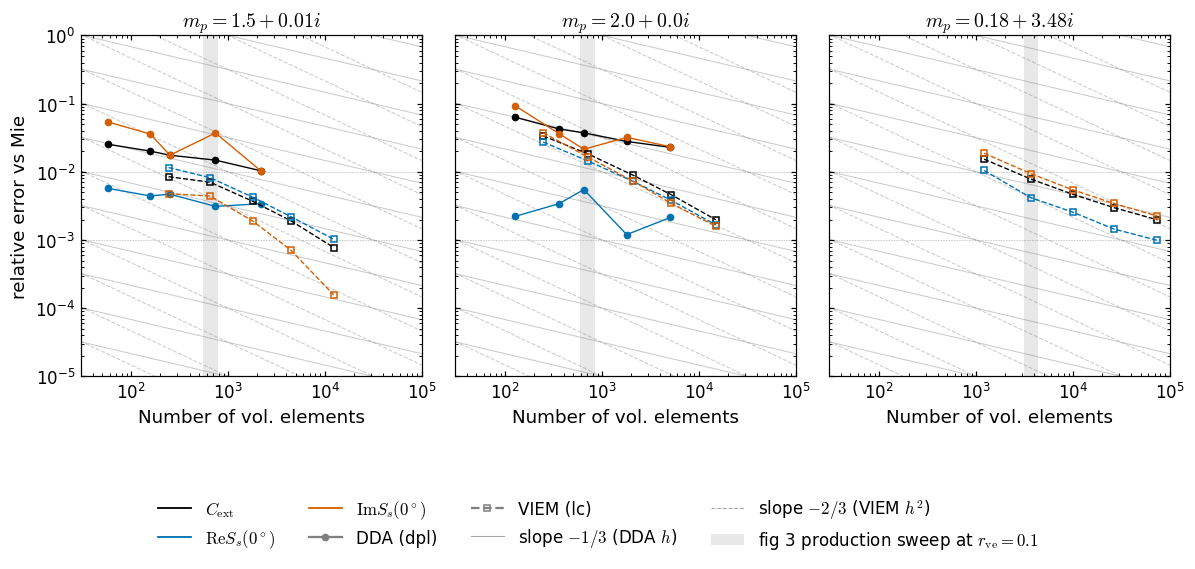

In [4]:
"""Phase 4 — dpl/lc convergence for sphere at r_ve=0.1 μm.

X-axis = number of volume elements: DDA dipole count vs VIEM tetrahedral count.
Three observables overlaid on each panel (one column per material):
  C_ext              : real-valued extinction cross-section.
  Re S_fw^θ          : real part of the polarised forward amplitude.
  Im S_fw^θ          : imag part of the polarised forward amplitude.
Galerkin theory on the SWG / cubic-lattice basis predicts the same h^2 rate
for every bounded linear functional, so the three observables share the
slope-(-2/3) (VIEM) and slope-(-1/3) (DDA) reference grids.

Slope reference grids drawn on every panel (matching fig 2's style):
  -2/3 (gray dashed) : VIEM h^2 convergence -> eps ∝ n_tet^(-2/3).
  -1/3 (gray solid)  : DDA  h   convergence -> eps ∝ N_dip^(-1/3),
                       since DDA polarisability error is O(h) not O(h^2).
"""

from matplotlib.patches import Patch

CONV_OBS = [
    ('C_ext',      'C_ext_mie', r'$C_{\rm ext}$',                       'real'),
    ('S_fw_theta', 'S_fw_mie',  r'$\mathrm{Re}S_s(0^\circ)$', 'real'),
    ('S_fw_theta', 'S_fw_mie',  r'$\mathrm{Im}S_s(0^\circ)$', 'imag'),
]
# Colour distinguishes the observable.  CUD-safe palette (Wong 2011):
# black for C_ext as the neutral 'total' cross-section, blue/vermillion
# for the complementary Re/Im pair of the same complex S_fw_theta.
# Matches fig 2's 3-observable combined figure.
PHASE4_OBS_COLORS = ['#000000', '#0072B2', '#D55E00']

# Fixed panel limits (uniform across all panels via sharex/sharey).
# YLIM matches fig 2's combined-figure YLIM = (1e-5, 1e0) for cross-
# figure consistency, so the sphere (fig 1) and non-sphere (fig 2)
# convergence panels are read on the same y-axis scale.
PHASE4_XLIM = (3.0e1, 1.0e5)
PHASE4_YLIM = (1.0e-5, 1.0e0)

# Slope reference grids: each line passes through (PHASE4_SLOPE_REF_X, ref_y)
# with the indicated slope; ref_y values half-decade spaced, identical per
# panel.  Anchor range now spans 1e-6 .. 10^{0.5} so that the slope lines
# fully tile the panel even at the corners (x=3e1 / y=1e-5 bottom-left and
# x=1e5 / y=1e0 top-right) — the previous narrower range left both
# corners unhatched.
PHASE4_SLOPE_REF_X  = 1.0e3
PHASE4_SLOPE_REF_YS = (1.0e-6, 10.0**(-5.5), 1.0e-5, 10.0**(-4.5),
                        1.0e-4, 10.0**(-3.5), 1.0e-3, 10.0**(-2.5),
                        1.0e-2, 10.0**(-1.5), 1.0e-1, 10.0**(-0.5),
                        1.0e0,  10.0**(+0.5))


def _conv_value(d, obs_key, kind):
    Y = d.get(obs_key)
    if Y is None:
        return None
    if kind == 'real':
        return np.real(Y)
    if kind == 'mag':
        return np.abs(Y)
    if kind == 'imag':
        return np.imag(Y)


def _ref_value(d, ref_key, kind):
    ref = d.get('reference')
    if ref is None or ref_key not in ref:
        return None
    v = ref[ref_key]
    if kind == 'real':
        return np.real(v)
    if kind == 'mag':
        return np.abs(v)
    if kind == 'imag':
        return np.imag(v)


def plot_phase4(save=True):
    fig, axes = plt.subplots(1, len(MATERIALS), figsize=(11, 5.8),
                              sharex=True, sharey=True)
    obs_colors = PHASE4_OBS_COLORS

    for j, mat in enumerate(MATERIALS):
        ax = axes[j]
        c = CONV.get(('sphere', mat), {})
        dda, viem = c.get('dda'), c.get('viem')
        if dda is None and viem is None:
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes, ha='center', va='center')
            continue

        # --- Slope reference grids (drawn first, behind data) -------------
        xs_grid = np.array(PHASE4_XLIM, dtype=float)
        for ref_y in PHASE4_SLOPE_REF_YS:
            # -2/3 dashed (VIEM h^2)
            a23 = ref_y * PHASE4_SLOPE_REF_X ** (2.0/3.0)
            ax.plot(xs_grid, a23 * xs_grid ** (-2.0/3.0),
                    ls='--', color='gray', lw=0.7, alpha=0.4, zorder=0)
            # -1/3 solid (DDA h)
            a13 = ref_y * PHASE4_SLOPE_REF_X ** (1.0/3.0)
            ax.plot(xs_grid, a13 * xs_grid ** (-1.0/3.0),
                    ls='-',  color='gray', lw=0.7, alpha=0.4, zorder=0)

        for src, dat, ls, marker in [
            ('DDA',  dda,  '-',  'o'),
            ('VIEM', viem, '--', 's'),
        ]:
            if dat is None:
                continue
            # DDA does not converge in the plasmonic-Au regime
            # (|m_p/m_m| ~ 3.5, see fig 1's companion discussion); only
            # VIEM is plotted on the Au panel.
            if src == 'DDA' and mat == 'Au':
                continue
            x_n = dat['n_dof'] if src == 'DDA' else dat['n_cuboid']

            for o_idx, (obs_key, ref_key, latex, kind) in enumerate(CONV_OBS):
                y = _conv_value(dat, obs_key, kind)
                yref = _ref_value(dat, ref_key, kind)
                if y is None or yref is None or yref == 0 or not np.isfinite(yref):
                    continue
                eps = np.abs(y - yref) / np.abs(yref)
                ax.plot(x_n, eps, ls=ls, marker=marker, markersize=4,
                        color=obs_colors[o_idx], lw=0.9,
                        mfc='none' if src == 'VIEM' else obs_colors[o_idx],
                        label=f'{src} {latex}' if j == 0 else None)

        # Mark fig-3 production sweep at r_ve=0.1 as a thin gray band spanning
        # [DDA n_occ, VIEM n_tet]. Both DDA (auto-dpl via dpl_for_slot) and VIEM
        # (adaptive_lc) pick lattice sizes automatically per slot.
        prod_dda  = DATA[('sphere', mat)]['dda']
        prod_viem = DATA[('sphere', mat)]['viem']
        if prod_dda is not None and prod_viem is not None:
            n_occ_p = prod_dda['cost'].get('n_occ')
            n_tet_p = prod_viem['cost'].get('n_tet')
            rve_p   = prod_dda['a_eq']
            if n_occ_p is not None and n_tet_p is not None:
                k01 = int(np.argmin(np.abs(np.asarray(rve_p) - 0.1)))
                if abs(rve_p[k01] - 0.1) < 1e-9:
                    center = float(np.sqrt(float(n_occ_p[k01])
                                            * float(n_tet_p[k01])))
                    half_w_log = 0.075   # → total visual width ≈ 0.15 decades
                    x_lo = center * 10.0 ** (-half_w_log)
                    x_hi = center * 10.0 ** (+half_w_log)
                    ax.axvspan(x_lo, x_hi, color='gray', alpha=0.18, lw=0,
                                zorder=0)

        # Horizontal reference lines at y=1e-2 and y=1e-3, matching fig 2.
        # 1e-3 = PHASE7_RESIDUAL_THRESHOLD (relaxed Au gate used across
        # fig 2 / fig 3 / fig 4); 1e-2 = upper-bound heuristic for the
        # plotted-range discretisation signal (see fig2_description.md
        # §6.3).  Drawn before set_xscale/set_yscale so the log axes pick
        # them up correctly.
        ax.axhline(1e-2, color='gray', lw=0.4, ls=':', zorder=0)
        ax.axhline(1e-3, color='gray', lw=0.4, ls=':', zorder=0)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.tick_params(axis='both', which='both', direction='in',
                        top=True, right=True, bottom=True, left=True,
                        labelsize=11)
        # Force square axis box (fig 2 panels are also nearly square).
        ax.set_box_aspect(1.0)
        ax.set_title(MATERIAL_LABEL[mat], fontsize=13)
        ax.set_xlabel('Number of vol. elements')
        if j == 0:
            ax.set_ylabel('relative error vs Mie')

    # Fixed panel limits propagated by sharex/sharey.
    axes[0].set_xlim(*PHASE4_XLIM)
    axes[0].set_ylim(*PHASE4_YLIM)

    handles_obs = [Line2D([], [], color=c, lw=1.2, label=latex)
                   for c, (_, _, latex, _) in zip(obs_colors, CONV_OBS)]
    handles_src = [
        Line2D([], [], color='gray', ls='-',  marker='o', markersize=4, label='DDA (dpl)'),
        Line2D([], [], color='gray', ls='--', marker='s', markersize=4,
               mfc='none', label='VIEM (lc)'),
    ]
    handles_slope = [
        Line2D([], [], color='gray', ls='-',  lw=0.7, alpha=0.7,
               label=r'slope $-1/3$ (DDA $h$)'),
        Line2D([], [], color='gray', ls='--', lw=0.7, alpha=0.7,
               label=r'slope $-2/3$ (VIEM $h^2$)'),
    ]
    handles_extra = [
        Patch(facecolor='gray', alpha=0.18, edgecolor='none',
               label=r'fig 3 production sweep at $r_{\rm ve}=0.1$'),
    ]
    fig.legend(handles=handles_obs + handles_src + handles_slope + handles_extra,
                ncol=4, loc='lower center', bbox_to_anchor=(0.5, 0.0), fontsize=11)
    plt.tight_layout(rect=(0, 0.14, 1, 0.99))
    if save:
        save_fig(fig, 'fig1_dpl_lc_convergence')
    plt.show()


plot_phase4()


## Section 5 — block-Krylov RHS scaling (sphere × {n15, n20, Au})

$L \in \{1, 2, 4, 8, 16, 32, 64, 128\}$. Per material panel-pair (iters / wall-per-orient).

Per (a_eq) curve: DDA (solid ○) vs VIEM (dashed □), color graded by $a_{\rm eq}$.

Expected: GMRES iter count ≈ flat in L (block solver advantage), wall-per-orient
∝ 1/L until cost of QR/Givens dominates.

<>:5: SyntaxWarning: invalid escape sequence '\i'
<>:5: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_8007/1719783389.py:5: SyntaxWarning: invalid escape sequence '\i'
  row 1 (top)    : residual ||r||/||b|| vs iter for L \in {1, 16, 128}.
/tmp/ipykernel_8007/1719783389.py:298: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0, 0.02, 1, 0.99))


saved fig4_rhs_scaling.{png,pdf}


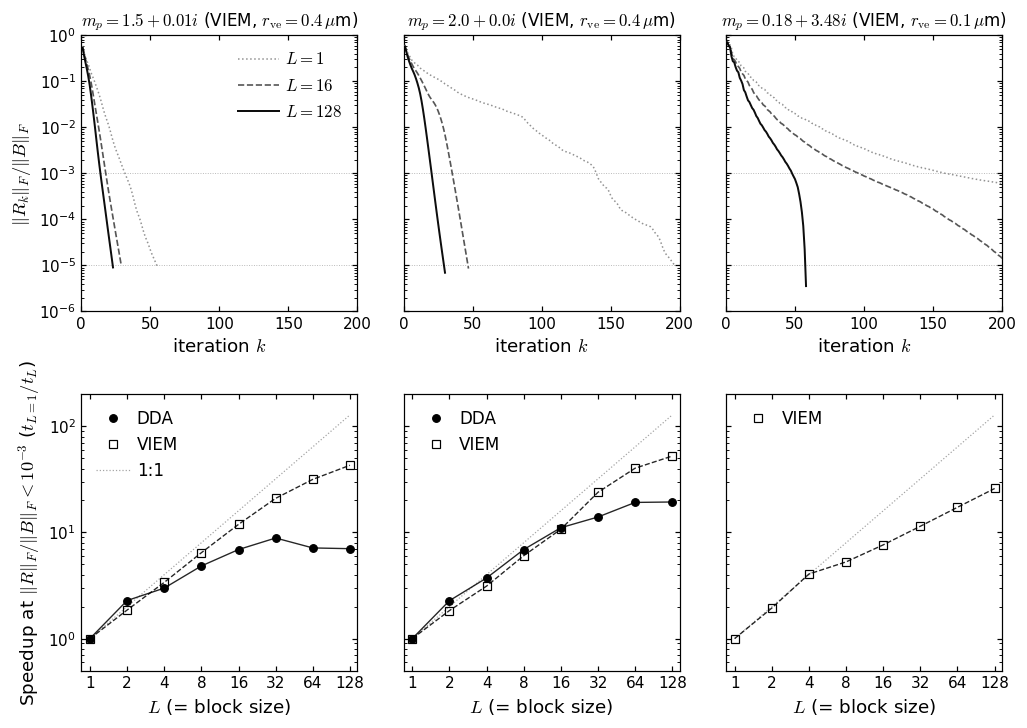

In [5]:
"""Phase 5 — block-Krylov per-RHS solving cost vs block size L
(paper figure 4 after the figure reorder; was figure 2).

2 x 3 panel layout:
  row 1 (top)    : residual ||r||/||b|| vs iter for L \in {1, 16, 128}.
                    Demonstrates *why* a larger L speeds up the per-RHS
                    cost: a richer Krylov subspace converges in fewer
                    iterations, with the gap between L=1 and L=128 most
                    pronounced for plasmonic Au.
  row 2 (bottom) : per-RHS solving cost t/L vs L (the original fig 4).
                    Same flat-vs-downward reading as before.

A single quantity per row-2 panel — solving time **per RHS** [s] (=
t_end2end_per_orient_s, equivalently total block solve time / L) —
captures the block-Krylov benefit directly: a flat curve means no
amortisation, a downward trend with L means block-Krylov pays off.

Per-panel content (chosen for clarity rather than exhaustive
coverage of the production grid):
  n15 / n20: r_ve = 0.40 \mu m — the largest production size; iter
             count there is high enough that block-Krylov amortisation
             is visible. Both DDA and VIEM in row 2; VIEM only in row 1
             (residual trace) to keep three curves per top panel.
  Au:        r_ve in {0.05, 0.10} \mu m (no 0.40 case for Au). VIEM
             only — DDA stalls at MAXITER for every L on every Au
             slot, with residuals above PHASE5_RESIDUAL_THRESHOLD =
             1e-3 (= the relaxed tol applied uniformly across fig 2 /
             fig 3 / fig 4 wherever Au plasmonic stalls appear).

Grayscale style — colour adds no information once the panel legend
is in place; the marker / linestyle / fill family carries solver and
r_ve identity. The residual-trace row distinguishes L by linestyle
(dotted L=1, dashed L=16, solid L=128) keeping the same gray family.
"""
from matplotlib.ticker import ScalarFormatter, FixedLocator

# Per-panel curves: list of (solver, r_ve, style_dict, legend_label).
PHASE5_PANELS = {
    'n15': [
        ('dda',  0.40,
            {'marker': 'o', 'mfc_fill': True,  'color': 'k',    'ls': '-'},
            'DDA'),
        ('viem', 0.40,
            {'marker': 's', 'mfc_fill': False, 'color': 'k',    'ls': '--'},
            'VIEM'),
    ],
    'n20': [
        ('dda',  0.40,
            {'marker': 'o', 'mfc_fill': True,  'color': 'k',    'ls': '-'},
            'DDA'),
        ('viem', 0.40,
            {'marker': 's', 'mfc_fill': False, 'color': 'k',    'ls': '--'},
            'VIEM'),
    ],
    'Au': [
        # r_ve = 0.05 μm dropped: too small to exhibit a clear
        # block-Krylov amortisation trend; the r_ve = 0.10 μm curve
        # alone carries the Au RHS-scaling story.
        ('viem', 0.10,
            {'marker': 's', 'mfc_fill': False, 'color': 'k',    'ls': '--'},
            'VIEM'),
    ],
}

# Top-row residual-trace selection: per material, pick (solver, r_ve)
# that matches the bottom row's primary curve so the rows tell a single
# coherent story for that slot.
PHASE5_TRACE_SLOT = {
    'n15': ('viem', 0.40),
    'n20': ('viem', 0.40),
    'Au':  ('viem', 0.10),
}

# L values to overlay on the residual-trace panels.
PHASE5_TRACE_L = (1, 16, 128)

# Style per L (grayscale + linestyle so colour stays neutral).
PHASE5_TRACE_STYLE = {
    1:   {'ls': ':',  'color': '0.55', 'lw': 1.0},
    16:  {'ls': '--', 'color': '0.30', 'lw': 1.1},
    128: {'ls': '-',  'color': 'k',    'lw': 1.3},
}

PHASE5_RESIDUAL_THRESHOLD = 1.0e-3


def _phase5_pick_residual_trace(rhs_dict, solver, k_pick, L_values, L_target):
    """Return residual_history[k_L, k_pick, :] for the requested L,
    NaN-trimmed.  None if data not available."""
    dat = rhs_dict.get(solver)
    if dat is None:
        return None
    rh = dat.get('residual_history')
    if rh is None:
        return None
    L_arr = np.asarray(dat['L_values']).ravel()
    matches = np.where(L_arr == L_target)[0]
    if matches.size == 0:
        return None
    k_L = int(matches[0])
    if k_pick >= rh.shape[1] or k_L >= rh.shape[0]:
        return None
    trace = np.asarray(rh[k_L, k_pick, :], dtype=float)
    # MAXITER axis is NaN-padded after solver termination.
    valid = ~np.isnan(trace)
    if not valid.any():
        return None
    last = int(np.where(valid)[0].max()) + 1
    return trace[:last]


def plot_phase5_combined(save=True):
    cols = list(PHASE5_PANELS.keys())
    fig, axes = plt.subplots(2, len(cols), figsize=(11, 7.5),
                              sharey='row',
                              gridspec_kw={'wspace': 0.10, 'hspace': 0.30})

    L_ref_global = None

    # ========================== Row 1: residual traces ==========================
    for j, mat in enumerate(cols):
        ax = axes[0, j]
        r = RHS.get(('sphere', mat), {})
        prod = DATA[('sphere', mat)]['dda'] or DATA[('sphere', mat)]['viem']
        if prod is None or not r:
            ax.set_visible(False)
            continue
        solver, rv = PHASE5_TRACE_SLOT.get(mat, (None, None))
        rve_grid = prod['a_eq']
        if solver is None or rv is None:
            ax.set_visible(False); continue
        k_pick = int(np.argmin(np.abs(rve_grid - rv)))
        if abs(rve_grid[k_pick] - rv) > 1e-9:
            ax.set_visible(False); continue
        dat = r.get(solver)
        if dat is None:
            ax.set_visible(False); continue
        L_values = np.asarray(dat['L_values']).ravel()
        if L_ref_global is None: L_ref_global = L_values

        for L_target in PHASE5_TRACE_L:
            tr = _phase5_pick_residual_trace(r, solver, k_pick,
                                              L_values, L_target)
            if tr is None or tr.size == 0:
                continue
            sty = PHASE5_TRACE_STYLE[L_target]
            iters_x = np.arange(1, tr.size + 1)
            ax.plot(iters_x, tr, ls=sty['ls'], color=sty['color'],
                    lw=sty['lw'], alpha=0.95, zorder=3,
                    label=f'$L={L_target}$' if j == 0 else None)

        ax.axhline(PHASE5_RESIDUAL_THRESHOLD, color='0.7', lw=0.6, ls=':',
                    zorder=1)
        ax.axhline(1.0e-5, color='0.7', lw=0.6, ls=':', zorder=1)
        ax.set_yscale('log')
        ax.tick_params(axis='both', which='both', direction='in',
                        top=True, right=True, bottom=True, left=True,
                        labelsize=10)
        ax.set_box_aspect(1.0)
        rv_label = (rv, solver.upper())
        ax.set_title(f'{MATERIAL_LABEL[mat]} '
                      f'({solver.upper()}, $r_{{\\rm ve}}={rv}\\,\\mu$m)',
                      fontsize=11)
        ax.set_xlabel(r'iteration $k$')
        if j == 0:
            ax.set_ylabel(r'$\|R_k\|_F / \|B\|_F$')
        if j == 0:
            ax.legend(loc='upper right', fontsize=11, frameon=False,
                       handlelength=2.4, handletextpad=0.4, borderaxespad=0.5)

    # Uniform iter axis: 0..200 (MAXITER); y axis covers 1e-6..1.
    for j in range(len(cols)):
        ax = axes[0, j]
        if ax.get_visible():
            ax.set_xlim(0, 200)
            ax.set_ylim(1.0e-6, 1.0e0)

    # ========================== Row 2: block-Krylov speedup factor ==============
    # Speedup definition (uniform across all 3 panels):
    #   t(L) = wall time per RHS to reach |r|/|b| < 1e-3, log-linearly
    #          interpolated from residual_history[L_idx, k_pick, :].
    #   speedup(L) = t(L=1) / t(L)
    # 1e-3 matches PHASE5_RESIDUAL_THRESHOLD (= the relaxed Au gate also
    # used in fig 2 / fig 3) and gives a properly apples-to-apples
    # comparison: at production termination (SOLVER_TOL=1e-5 or MAXITER)
    # the residuals of different L can land at different levels, which
    # would conflate "more iterations saved" with "deeper residual reached".
    # Restricting both numerator and denominator to the same residual
    # threshold removes that confound.
    def _iter_to_threshold(rh_trace, thresh):
        # Linearly-on-log iter count at which residual first reaches thresh.
        # Returns float (1-indexed iter, may be fractional), or None if
        # the trace never falls below thresh.
        tr = np.asarray(rh_trace, dtype=float)
        valid = ~np.isnan(tr)
        if not valid.any(): return None
        below = valid & (tr < thresh)
        if not below.any(): return None
        k_first = int(np.where(below)[0][0])
        if k_first == 0:
            return 1.0
        r0 = float(tr[k_first - 1]); r1 = float(tr[k_first])
        if r0 <= 0 or r1 <= 0 or r0 == r1:
            return float(k_first + 1)
        frac = np.log(thresh / r0) / np.log(r1 / r0)
        return float(k_first + frac)

    THRESH = PHASE5_RESIDUAL_THRESHOLD

    for j, mat in enumerate(cols):
        ax = axes[1, j]
        r = RHS.get(('sphere', mat), {})
        prod = DATA[('sphere', mat)]['dda'] or DATA[('sphere', mat)]['viem']
        if prod is None or not r:
            ax.set_visible(False)
            continue
        rve_grid = prod['a_eq']
        for src_label, rv, style, label in PHASE5_PANELS[mat]:
            dat = r.get(src_label)
            if dat is None: continue
            k_pick = int(np.argmin(np.abs(rve_grid - rv)))
            if abs(rve_grid[k_pick] - rv) > 1e-9: continue
            L = np.asarray(dat['L_values']).ravel()
            if L_ref_global is None: L_ref_global = L
            t_per = dat.get('t_end2end_per_orient_s')
            iters_arr = dat.get('iters')
            rh = dat.get('residual_history')
            if t_per is None or iters_arr is None or rh is None: continue
            if k_pick >= t_per.shape[1]: continue
            tk_term = np.asarray(t_per[:, k_pick], dtype=float)
            it_done = np.asarray(iters_arr[:, k_pick], dtype=float)

            # Iter count to res<thresh per L.  None if not reached.
            iter_thresh = np.full(len(L), np.nan)
            for kL in range(len(L)):
                v = _iter_to_threshold(rh[kL, k_pick, :], THRESH)
                if v is not None:
                    iter_thresh[kL] = v

            # t_to_thresh by linear scaling of wall time: assume per-iter
            # block cost is constant within a single solve, so
            #   t_to_thresh = (iter_thresh / iters_done) * t_per_term
            with np.errstate(divide='ignore', invalid='ignore'):
                t_thresh = (iter_thresh / it_done) * tk_term

            ok = np.isfinite(t_thresh) & (t_thresh > 0)
            # Baseline: t_to_thresh at L=1.  If L=1 didn't reach thresh,
            # this curve is skipped (cannot define a 1e-3 baseline).
            k_L1 = int(np.argmin(np.abs(L - 1)))
            if abs(L[k_L1] - 1) > 1e-9 or not ok[k_L1]:
                continue
            t1 = t_thresh[k_L1]
            speedup = t1 / t_thresh

            mfc = style['color'] if style['mfc_fill'] else 'none'
            ax.plot(L[ok], speedup[ok], ls=style['ls'], color=style['color'],
                    lw=0.9, alpha=0.85, zorder=2)
            ax.plot(L[ok], speedup[ok], ls='', marker=style['marker'],
                    markersize=5, color=style['color'], mfc=mfc, mew=0.8,
                    zorder=3, label=label)

        # Ideal speedup line y = L (perfect amortisation).
        if L_ref_global is not None:
            L_dense = np.geomspace(L_ref_global[0], L_ref_global[-1], 64)
            ax.plot(L_dense, L_dense, ls=':', color='0.55', lw=0.8,
                    alpha=0.8, zorder=1,
                    label='1:1' if j == 0 else None)

        ax.set_xscale('log')
        ax.set_yscale('log')
        if L_ref_global is not None:
            ax.xaxis.set_major_locator(FixedLocator(L_ref_global))
            ax.xaxis.set_minor_locator(FixedLocator([]))
            ax.xaxis.set_major_formatter(ScalarFormatter())
            ax.set_xlim(L_ref_global[0] * 0.85, L_ref_global[-1] * 1.15)
        ax.tick_params(axis='both', which='both', direction='in',
                        top=True, right=True, bottom=True, left=True,
                        labelsize=10)
        ax.set_box_aspect(1.0)
        ax.set_xlabel(r'$L$ (= block size)')
        if j == 0:
            ax.set_ylabel(r'Speedup at $\|R\|_F/\|B\|_F<10^{-3}$ '
                          r'($t_{L=1}/t_{L}$)')
        ax.legend(loc='upper left', fontsize=11, frameon=False,
                   handlelength=2.0, handletextpad=0.4, borderaxespad=0.5)

    # Y range row 2: speedup axis fixed at (0.5, 2e2).  Lower bound 0.5
    # flags visually if L hurt vs L=1 (sub-1x).  Upper bound 2e2 sits
    # above the largest measured speedup (~1.5e2) and the ideal y=L
    # line (max 128) with comfortable headroom.
    SPEEDUP_YLIM_LO = 0.5
    SPEEDUP_YLIM_HI = 2.0e2
    for j in range(len(cols)):
        ax = axes[1, j]
        if ax.get_visible():
            ax.set_ylim(SPEEDUP_YLIM_LO, SPEEDUP_YLIM_HI)

    plt.tight_layout(rect=(0, 0.02, 1, 0.99))
    if save:
        save_fig(fig, 'fig4_rhs_scaling')
    plt.show()


plot_phase5_combined()


## Section 6 — Cost summary table

Per-file totals (summed over a_eq slots) for both DDA and VIEM. Mirrors
`dda_results/paper/cost_estimates.md`.

In [6]:
"""Phase 6 — cost summary, paired DDA / VIEM totals per (shape, material)."""

def cost_summary_table():
    rows = []
    for shape in SHAPES:
        for mat in MATERIALS:
            e = DATA[(shape, mat)]
            for src, dat in [('DDA', e['dda']), ('VIEM', e['viem'])]:
                if dat is None or 'cost' not in dat or not dat['cost']:
                    continue
                c = dat['cost']
                if 't_total_s' not in c:
                    continue
                t_total_min = float(np.nansum(c['t_total_s'])) / 60
                peak_GB     = float(np.nanmax(c.get('peak_rss_bytes', [0]))) / 1024**3
                conv        = c.get('converged', np.zeros(1, dtype=int))
                n_conv      = int(np.nansum(conv))
                n_slot      = int(np.size(conv))
                iters_max   = int(np.nanmax(c.get('iters', [0])))
                rows.append((src, f'{shape}_{mat}',
                             n_conv, n_slot, t_total_min, peak_GB, iters_max))

    print(f"{'src':<5}{'file':<14} {'conv':<7} {'wall (min)':<12}"
          f" {'peak RSS (GB)':<15} {'max iters':<10}")
    print('-' * 70)
    tot_t = {'DDA': 0.0, 'VIEM': 0.0}
    peak_rss = {'DDA': 0.0, 'VIEM': 0.0}
    for src, name, nc, ns, t, rss, mi in rows:
        print(f'{src:<5}{name:<14} {nc}/{ns:<5} {t:<12.2f} {rss:<15.2f} {mi}')
        tot_t[src] += t
        peak_rss[src] = max(peak_rss[src], rss)
    print('-' * 70)
    for src in ('DDA', 'VIEM'):
        print(f'{src:<5}{"TOTAL":<14}        {tot_t[src]:<12.2f} '
              f'(peak {peak_rss[src]:.2f})')


cost_summary_table()

src  file           conv    wall (min)   peak RSS (GB)   max iters 
----------------------------------------------------------------------
DDA  sphere_n15     4/4     0.25         0.54            22
VIEM sphere_n15     4/4     2.15         4.36            39
DDA  sphere_n20     4/4     1.26         1.53            70
VIEM sphere_n20     4/4     3.75         9.69            88
DDA  sphere_Au      0/3     4.13         1.85            200
VIEM sphere_Au      1/3     4.51         6.50            200
DDA  oblate_n15     4/4     0.30         0.61            22
VIEM oblate_n15     4/4     2.99         4.42            39
DDA  oblate_n20     4/4     1.26         1.47            66
VIEM oblate_n20     4/4     4.35         9.13            84
DDA  oblate_Au      0/3     4.81         1.86            200
VIEM oblate_Au      0/3     5.04         6.34            200
DDA  gre_n15        4/4     12.69        27.92           11
VIEM gre_n15        4/4     33.72        14.30           51
DDA  gre_n20     

## Section 7 — VIEM $\ell_c$ self-convergence on non-sphere production shapes (oblate + GRE)

VIEM-only extension of Section 4. Same single-orientation convergence sweep
(`viem_results/paper/run_lc_convergence.jl`, ZYZ identity orientation
$\alpha=\beta=\gamma=0$, $r_{\rm ve}=0.1\,\mu$m) but on the **non-sphere**
target shapes — oblate spheroid ($a/b=1$, $b/c=3$) and GRE
($\beta_{\rm gre}=0.2$).

Two reference choices are overlaid where data permits:

**TMM reference at $\beta=0$** (oblate only): the convergence-sweep
orientation $(\alpha,\beta,\gamma)=(0,0,0)$ is now covered by a
dedicated EBCM (T-matrix) computation, `tmm_oblate_conv_<mat>.hdf5`,
produced by
[`run_tmatrix_oblate_conv_reference.jl`](../../../../Julia/block-VIEM.jl/viem_results/paper/run_tmatrix_oblate_conv_reference.jl).
The pre-pulled production `tmm_oblate_*.hdf5` files are kept untouched —
they cover the production $\beta$ grid (cos $\beta\in\{\pm 0.8,\pm 0.4,0\}$)
needed by Section 3 / fig 3. ε vs TMM uses filled circles ●, solid line.

**Richardson extrapolation** (all panels): 2-point Richardson at the
two finest meshes assuming the SWG h² rate, $X_\infty^{\rm Rich} =
(r^p y_{\rm fine} - y_{\rm 2nd})/(r^p-1)$ with $r^p =
(n_{\rm fine}/n_{\rm 2nd})^{p/3}$, $p=2$. ε vs Richardson uses open
squares □, dashed line. This is the only available reference for GRE
(no exact analytical solution).

The two curves on oblate panels should track each other to within
$\mathcal O(h^4)$ + solver residual; their visual co-linearity validates
the Richardson approach used as the sole reference on the GRE row.

**Single observable: $|S_{\rm fw}^\theta|$**. CAS-v2 polarimetric
forward amplitude — the headline observable that the downstream
Bayesian retrieval consumes directly. Convergence universality across
multiple observables is already covered by fig 1 (sphere, Mie ref);
fig 4 isolates the most paper-relevant scalar to maximise the visual
punch of the dual TMM ⟷ Richardson overlay. Galerkin theory predicts
the same $h^2$ rate for every bounded linear functional of the SWG
solution, so the shape-universality argument needs only one
representative observable.

$|S_{\rm bk}|$ is **excluded** specifically because at the
convergence-sweep slot (axisymmetric oblate at axial incidence
$\beta=0$) TMM gives $|S_{\rm bk}|=0$: $S_1(180°)=-S_2(180°)$ +
off-diagonals vanish ⇒ the CAS-v2 LCP-projected back-amplitude
vanishes by construction. This is **not a general TMM property**:
$|S_{\rm bk}|\ne 0$ at $\beta\ne 0$ for axisymmetric shapes and at
any orientation for non-axisymmetric shapes (GRE). The
relative-error denominator $|S_{\rm bk}^{\rm TMM}|=0$ at our
specific $\beta=0$ slot makes $\varepsilon$ undefined; we exclude
rather than special-case.

$Q_{\rm ext}$ and $Q_{\rm abs}$ are excluded as redundant with fig 1
(Q_abs additionally noisy on n15 due to small Im $m_p$).

- **Rows**: oblate (3:3:1), GRE ($\beta_{\rm gre}=0.2$).
- **Cols**: n15, n20, Au.
- **Reference pair (Richardson)**: $(\ell_c^{\rm factor}=0.5, 0.35)$ for oblate (5 points), $(1.0, 0.7)$ for GRE (3 points).
- Stalled $\ell_c$ points (MAXITER=200) → `×` marker.

**Au residual-threshold gate (paper Option B).** For Au every lc point
exits at MAXITER (200 for oblate, 400 for GRE) with non-zero
$\|r\|/\|b\|$. Both the TMM overlay and the Richardson curve are
kept only if $\|r\|/\|b\|$ at the two finest meshes is below
$10^{-3}$ — a 100× relaxation of the convergence criterion bounding
the observable bias to $\sim 10^{-2}$ in the plasmonic regime
($\kappa(A)\approx 10$ empirically). Au panels are run with a
block-Krylov subspace expansion (BLOCK_SIZE=128 for GRE Au, 64 for
oblate Au) to break the single-orientation stall while keeping the
column-0 observable identical to the L=1 single-orientation result.
Per-series result with the regenerated convergence sweeps (m3,
2026-04-30 / 2026-05-01):

| Series | $\|r\|/\|b\|$ at finest pair | gate $10^{-3}$ | fig 4 action |
| --- | ---: | :---: | --- |
| oblate × Au | $7.0\times 10^{-5},\ 2.0\times 10^{-4}$ | ✅ | TMM + Richardson kept |
| gre × Au    | $5.2\times 10^{-6},\ 3.0\times 10^{-4}$ | ✅ | Richardson kept |

Detailed derivation in [`fig4_description.md` §6.3](fig4_description.md).


Phase 7: loaded 3 oblate TMM β=0 reference files


saved fig2_C_ext_S_fw_theta_ReIm_lc_convergence_nonsphere.{png,pdf}


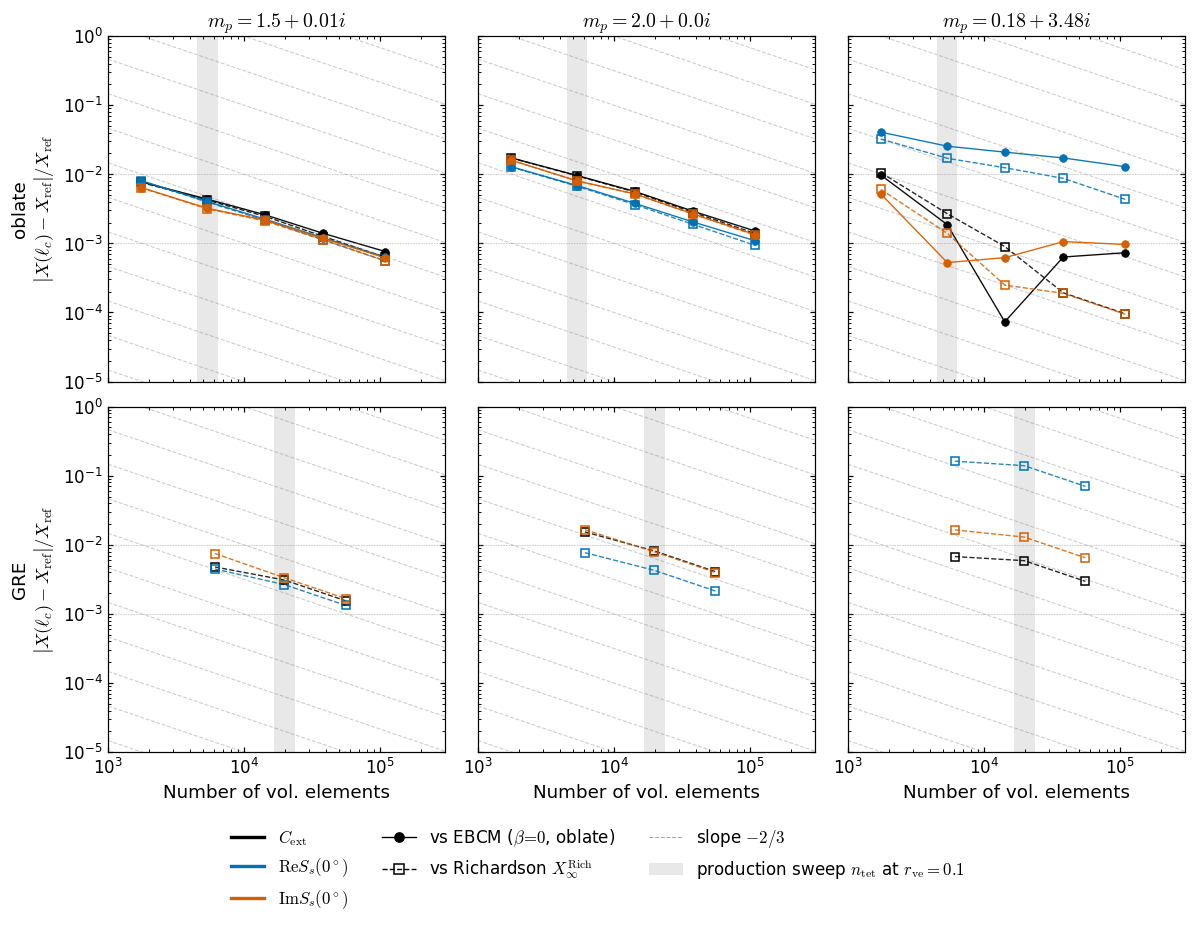

In [7]:
"""Phase 7 — VIEM ℓ_c convergence on non-sphere production shapes.

fig4_lc_convergence_nonsphere.{png,pdf} — 2 × 3 panels:
  Rows: oblate (3:3:1), GRE (β_gre=0.2)
  Cols: n15 (m_p=1.5+0.01i), n20 (m_p=2.0), Au (m_p=0.18+3.48i)

Y-axis: relative error |X(ℓ_c) − X_ref| / |X_ref|, plotted against
n_tet on log-log axes. Two reference choices are overlaid where data
permits, with distinct marker / linestyle:

  TMM (oblate only):  X_ref = X_TMM at (a_eq=0.1, β=0)  — exact axisymmetric
    EBCM result from `tmm_oblate_conv_<mat>.hdf5` (run_tmatrix_oblate_conv_
    reference.jl). Filled circle ●, solid line.
  Richardson (all):   X_ref = X_∞^Rich, 2-point Richardson extrapolation
    of the two finest VIEM meshes assuming the SWG h^2 rate:
        X_∞^Rich = (r^p · y_fine − y_2nd) / (r^p − 1),
        r^p = (n_fine / n_2nd)^(p/3),  p = 2.
    Open square □, dashed line.

The TMM and Richardson curves should overlap at the production lc range,
giving a direct cross-check of the Richardson-only treatment used on the
GRE row (where no exact reference exists).

Single observable: |S_fw_θ| — CAS-v2 polarimetric forward amplitude,
the headline scalar of the paper. fig 1 already established convergence
universality across {Q_ext, Q_abs, |S_fw_θ|, |S_bk|} on sphere; the
remaining task for fig 4 is to demonstrate **shape**-universality of
the same h^2 rate, which one observable suffices for (Galerkin theory:
all bounded linear functionals share the same rate).

|S_bk| is excluded for a slot-specific reason: at axisymmetric oblate
+ axial incidence (β=0), TMM gives |S_bk|=0 by construction
(S₁(180°)=−S₂(180°) + off-diagonals zero ⇒ LCP back-amplitude
vanishes). |S_bk| is generally non-zero in TMM for β≠0 or non-axi-
symmetric shapes; the zero is specific to our convergence slot.
Relative-error denominator = 0 → ε undefined → excluded.

Q_ext, Q_abs are excluded as redundant with fig 1 (Q_abs is also
noisy on n15 due to small Im m_p).

Slope vs n_tet recovers the SWG discretization order p = 2 ⇒ slope −2/3.
The slope guide is anchored at the TMM curve's 2nd-finest point on
oblate panels (or the Richardson curve's 2nd-finest on GRE panels).

Residual-threshold gate (paper-policy Option B). Stalled-residual
contamination of X_∞^Rich is acceptable only when ‖r‖/‖b‖ at both
finest meshes is below PHASE7_RESIDUAL_THRESHOLD = 1e-3 (justification
in fig4_description.md §6.3). Series failing the gate are not plotted;
the panel shows the final residuals as a textual annotation.
After the m3 regeneration (BLOCK_SIZE=128 GRE Au with MAXITER=400, and
BLOCK_SIZE=64 oblate Au, lc convergence sweep, 2026-04-30 / 2026-05-01),
both Au series pass the gate: oblate Au finest-pair residuals 7.0e-5,
2.0e-4; GRE Au finest-pair residuals 5.2e-6, 3.0e-4 (Richardson kept,
no TMM reference for GRE).
"""

from matplotlib.patches import Patch  # noqa: E402  — local to Phase 7

PHASE7_RESIDUAL_THRESHOLD = 1.0e-3
PHASE7_SHAPES = ['oblate', 'gre']

# Fixed panel limits — uniform across all panels via sharex/sharey.
PHASE7_XLIM = (1.0e3, 3.0e5)
PHASE7_YLIM = (1.0e-4, 2.0e-2)

# Slope-(-2/3) reference grid: 6 parallel lines passing through
# (PHASE7_SLOPE_REF_X, ref_y) for ref_y in PHASE7_SLOPE_REF_YS, with
# slope -2/3 in log-log. Identical on every panel (no per-panel LSQ
# fit) so the same reference grid frames every dataset.
PHASE7_SLOPE_REF_X  = 1.0e4
# 0.5-decade spaced anchors. Anchor range now spans 1e-6 .. 10^{+1} so
# the slope grid fully tiles the YLIM = (1e-5, 1e0) panel even at the
# corners (x=1e3 / y=1e-5 bottom-left and x=3e5 / y=1e0 top-right).
# Lines outside a given panel's YLIM are clipped by matplotlib, so the
# same grid set is reused across all observables.
PHASE7_SLOPE_REF_YS = (1.0e-6, 10.0**(-5.5), 1.0e-5, 10.0**(-4.5),
                        1.0e-4, 10.0**(-3.5), 1.0e-3, 10.0**(-2.5),
                        1.0e-2, 10.0**(-1.5), 1.0e-1, 10.0**(-0.5),
                        1.0e0,  10.0**(+0.5), 1.0e1)

# Single observable for fig 4 (paper editorial decision): |S_fw_θ| is
# the polarimetric forward amplitude that the CAS-v2 retrieval consumes
# directly — the headline observable of this paper. fig 1 already
# established convergence universality across {Q_ext, Q_abs, |S_fw_θ|,
# |S_bk|} on sphere via the Galerkin theory of linear functionals on
# the SWG basis (rate is shared by all bounded linear functionals); fig
# 4 therefore needs only one observable to demonstrate the **shape**
# universality of the same h^2 rate on non-sphere targets.
#
# |S_bk| is excluded because TMM gives |S_bk|=0 specifically for an
# axisymmetric particle at axial incidence (β=0): S₁(180°)=−S₂(180°)
# and off-diagonals vanish, so the CAS-v2 LCP-projected back-amplitude
# vanishes by construction. (TMM |S_bk| is generally non-zero — for
# axisymmetric particles at β≠0, or any orientation of non-axisymmetric
# particles like GRE.) The relative-error denominator |S_bk^TMM|=0 in
# our convergence-sweep slot makes ε undefined; we exclude rather than
# special-case.
#
# Q_abs is excluded to avoid small-Im(m_p) numerical noise on n15;
# Q_ext is excluded as redundant with fig 1 and to maximise the visual
# punch of the dual TMM ⟷ Richardson overlay on a single observable.
PHASE7_OBS_FIG4 = [
    ('S_fw_theta', r'$|S_{\rm fw}^{\theta}|$', 'mag'),
]

# Reference-method colour scheme. With a single observable, the line
# colour now distinguishes the reference choice (TMM vs Richardson)
# rather than the observable.
PHASE7_TMM_COLOR  = 'C0'   # blue, solid, filled circle
PHASE7_RICH_COLOR = 'C3'   # red,  dashed, open square

# TMM β=0 reference for oblate panels — pre-load once.
PHASE7_CONV_REF = {}
for _mat in MATERIALS:
    _p = VIEM_DIR / f'tmm_oblate_conv_{_mat}.hdf5'
    if _p.is_file():
        _ref = _try(load_tmm, _p)
        if _ref is not None:
            PHASE7_CONV_REF[('oblate', _mat)] = _ref
print(f'Phase 7: loaded {len(PHASE7_CONV_REF)} oblate TMM β=0 reference files')


def _phase7_richardson_x_inf(y, x_n, p=2.0):
    """Two-point Richardson X_∞ from the two finest meshes (h ∝ n_tet^{-1/3}).
    Returns float or None when ill-conditioned."""
    if y is None:
        return None
    y   = np.asarray(y,   dtype=float)
    x_n = np.asarray(x_n, dtype=float)
    if len(y) < 2 or len(x_n) != len(y):
        return None
    order  = np.argsort(x_n)
    i_fine, i_2nd = order[-1], order[-2]
    if x_n[i_fine] <= 0 or x_n[i_2nd] <= 0 or x_n[i_fine] == x_n[i_2nd]:
        return None
    r_p = (x_n[i_fine] / x_n[i_2nd]) ** (p / 3.0)
    if abs(r_p - 1.0) < 1e-9:
        return None
    X_inf = (r_p * y[i_fine] - y[i_2nd]) / (r_p - 1.0)
    return X_inf if np.isfinite(X_inf) and X_inf != 0 else None


def _phase7_relerr_against(y, x_inf):
    """ε_i = |y_i − X_inf| / |X_inf| for every i; None if X_inf is invalid."""
    if x_inf is None or not np.isfinite(x_inf) or x_inf == 0:
        return None
    return np.abs(np.asarray(y, dtype=float) - x_inf) / abs(x_inf)


def _phase7_kind_to_scalar(v, kind):
    """Map a (possibly complex) reference value to its plot-axis scalar."""
    if v is None:
        return None
    if kind == 'real':
        return float(np.real(v))
    if kind == 'mag':
        return float(np.abs(v))
    if kind == 'imag':
        return float(np.imag(v))
    return None


def plot_phase7(obs_list=None, latex_short=None, fig_basename=None,
                ylim=None, obs_colors=None, legend_obs_labels=None,
                save=True):
    """Render the 2x3 lc-convergence figure for one or several observables.

    Parameters
    ----------
    obs_list : list of (obs_key, latex_label, kind) tuples or None
        Observable spec passed through to _conv_value.  None defaults to
        PHASE7_OBS_FIG4 (= |S_fw^θ|, kind='mag').
    latex_short : str or None
        LaTeX fragment used inside the title and y-axis labels (e.g.
        r'|S_{\rm fw}^{\theta}|' or r'C_{\rm ext}').  None defaults
        to the |S_fw^θ| string matching the obs_list default.  In
        combined-observable mode pass a generic placeholder like 'X' —
        the per-observable identification is then carried by the legend.
    fig_basename : str or None
        File basename (no extension) passed to save_fig().  None
        defaults to 'fig2_lc_convergence_nonsphere'.
    ylim : tuple (lo, hi) or None
        Per-figure y-axis limits (relative-error range).
    obs_colors : list of color or None
        Single-observable mode (None, default): TMM and Richardson are
        drawn in PHASE7_TMM_COLOR / PHASE7_RICH_COLOR (blue / red), so
        colour distinguishes the reference choice.
        Combined mode (list): each obs in obs_list gets the colour at
        the matching index, and the same colour is reused for both its
        TMM and Richardson curves.  TMM vs Richardson are then
        distinguished by line/marker style only (solid + filled circle
        vs dashed + open square).
    legend_obs_labels : list of str or None
        In combined mode, LaTeX labels for the per-observable colour
        legend entries.  Defaults to the latex_label slot of obs_list.
    """
    if obs_list is None:
        obs_list = PHASE7_OBS_FIG4
    if latex_short is None:
        latex_short = r'|S_{\rm fw}^{\theta}|'
    if fig_basename is None:
        fig_basename = 'fig2_lc_convergence_nonsphere'
    if ylim is None:
        ylim = PHASE7_YLIM
    multi_obs_mode = obs_colors is not None
    if multi_obs_mode and len(obs_colors) != len(obs_list):
        raise ValueError(
            f'len(obs_colors) = {len(obs_colors)} must match '
            f'len(obs_list) = {len(obs_list)} in combined mode')
    if multi_obs_mode and legend_obs_labels is None:
        legend_obs_labels = [t[1] for t in obs_list]

    # figsize matched to fig 1's per-panel aspect: fig 1 uses (11, 4) for
    # 1x3 -> ~3.67 x 4 per panel. Doubling the height for 2x3 here gives
    # the same per-panel aspect; h_pad in tight_layout (below) tightens
    # the row gap.
    fig, axes = plt.subplots(len(PHASE7_SHAPES), len(MATERIALS),
                              figsize=(11, 8),
                              sharex=True, sharey=True)

    for i, shape in enumerate(PHASE7_SHAPES):
        for j, mat in enumerate(MATERIALS):
            ax = axes[i, j]
            c = CONV.get((shape, mat), {})
            viem = c.get('viem')
            if (viem is None
                    or viem.get('n_cuboid') is None
                    or len(viem['n_cuboid']) < 2):
                ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                         ha='center', va='center', fontsize=12, color='gray')
                if i == 0:
                    ax.set_title(MATERIAL_LABEL[mat], fontsize=13)
                if j == 0:
                    ax.set_ylabel({'oblate': 'oblate', 'gre': 'GRE'}.get(shape, shape))
                continue

            x_n  = np.asarray(viem['n_cuboid'], dtype=float)   # = n_tet
            n_lc = len(x_n)
            converged = np.asarray(
                viem.get('converged', np.ones(n_lc)), dtype=bool)
            solver_err = viem.get('solver_err')
            if solver_err is not None:
                solver_err = np.asarray(solver_err, dtype=float)

            # Per-point marker mask. Au panels are run with a relaxed
            # effective tolerance (PHASE7_RESIDUAL_THRESHOLD = 1e-3) since
            # the production tol = 1e-5 is unreachable in the plasmonic
            # regime; the whole panel is treated as gate-pass and every
            # point uses the OK glyph (filled circle / open square),
            # matching non-Au panels visually. The relaxed-tol caveat is
            # noted in the paper body / figure caption.
            if mat == 'Au':
                eff_conv = np.ones_like(converged, dtype=bool)
            else:
                eff_conv = converged

            order  = np.argsort(x_n)
            i_2nd  = order[-2] if n_lc >= 2 else order[-1]
            i_fine = order[-1]

            # Residual-threshold gate (paper Option B). After the m3
            # regeneration with block-Krylov subspace expansion
            # (BLOCK_SIZE=128 GRE Au + MAXITER=400, BLOCK_SIZE=64 oblate
            # Au), both Au series pass the gate. The dynamic check below
            # remains as a guard for future regressions.
            if (solver_err is not None
                    and (solver_err[i_fine] > PHASE7_RESIDUAL_THRESHOLD
                         or solver_err[i_2nd] > PHASE7_RESIDUAL_THRESHOLD)):
                seq = ', '.join(f'{s:.1e}' for s in solver_err[order])
                ax.text(
                    0.5, 0.55,
                    'Richardson / TMM\nplot skipped\n'
                    + r'($\|r\|/\|b\|$ at finest pair'
                    + f' > {PHASE7_RESIDUAL_THRESHOLD:.0e})',
                    transform=ax.transAxes,
                    ha='center', va='center', fontsize=11, color='C3',
                )
                ax.text(
                    0.5, 0.28,
                    'final residuals (coarse → fine):\n' + seq,
                    transform=ax.transAxes,
                    ha='center', va='center', fontsize=10, color='gray',
                    family='monospace',
                )
                ax.set_xscale('log'); ax.set_yscale('log')
                ax.tick_params(axis='both', which='both', direction='in',
                                top=True, right=True, bottom=True, left=True,
                                labelsize=11)
                if i == 0:
                    ax.set_title(MATERIAL_LABEL[mat], fontsize=13)
                if j == 0:
                    ax.set_ylabel({'oblate': 'oblate', 'gre': 'GRE'}.get(shape, shape) + '\n'
                                  + r'$\left| ' + latex_short + r'(\ell_c)'
                                  + r'-{' + latex_short + r'}_{\rm ref}'
                                  + r'\right|/{' + latex_short + r'}_{\rm ref}$')
                if i == len(PHASE7_SHAPES) - 1:
                    ax.set_xlabel('Number of vol. elements')
                continue

            anchor_set = False
            tmm_ref = PHASE7_CONV_REF.get((shape, mat))   # None for GRE
            for idx_obs, (obs_key, _latex, kind) in enumerate(obs_list):
                # Single-obs mode: blue TMM / red Richardson (current).
                # Multi-obs mode: per-obs colour reused for both refs;
                # TMM vs Richardson distinguished by line/marker style.
                if multi_obs_mode:
                    rich_color = obs_colors[idx_obs]
                    tmm_color  = obs_colors[idx_obs]
                else:
                    rich_color = PHASE7_RICH_COLOR
                    tmm_color  = PHASE7_TMM_COLOR
                y = _conv_value(viem, obs_key, kind)
                if y is None or len(y) != n_lc:
                    continue
                y = np.asarray(y, dtype=float)

                # ----- Richardson curve (always drawn when defined) -------
                X_rich = _phase7_richardson_x_inf(y, x_n, p=2.0)
                eps_r  = _phase7_relerr_against(y, X_rich)
                if eps_r is not None:
                    m_fin = np.isfinite(eps_r) & (eps_r > 0)
                    ax.plot(x_n[m_fin], eps_r[m_fin], ls='--',
                            color=rich_color, lw=0.9, alpha=0.85,
                            zorder=2)
                    m_ok  = m_fin & eff_conv
                    m_stl = m_fin & ~eff_conv
                    ax.plot(x_n[m_ok], eps_r[m_ok], ls='', marker='s',
                            markersize=5, color=rich_color,
                            mfc='none', mew=1.0, zorder=3)
                    if m_stl.any():
                        ax.plot(x_n[m_stl], eps_r[m_stl], ls='', marker='x',
                                markersize=8, mew=1.4,
                                color=rich_color, zorder=4)

                # ----- TMM curve (oblate only, when β=0 ref available) ---
                eps_t = None
                if tmm_ref is not None:
                    ref_v = tmm_ref.get(obs_key)
                    if ref_v is not None:
                        if hasattr(ref_v, 'shape') and ref_v.ndim >= 2:
                            ref_scalar = _phase7_kind_to_scalar(
                                ref_v[0, 0], kind)
                        else:
                            ref_scalar = _phase7_kind_to_scalar(ref_v, kind)
                        eps_t = _phase7_relerr_against(y, ref_scalar)
                        if eps_t is not None:
                            m_fin = np.isfinite(eps_t) & (eps_t > 0)
                            ax.plot(x_n[m_fin], eps_t[m_fin], ls='-',
                                    color=tmm_color, lw=0.9,
                                    alpha=0.95, zorder=2)
                            m_ok  = m_fin & eff_conv
                            m_stl = m_fin & ~eff_conv
                            ax.plot(x_n[m_ok], eps_t[m_ok], ls='', marker='o',
                                    markersize=5, color=tmm_color,
                                    mfc=tmm_color, mew=0.5, zorder=3)
                            if m_stl.any():
                                ax.plot(x_n[m_stl], eps_t[m_stl], ls='',
                                        marker='x', markersize=8, mew=1.4,
                                        color=tmm_color, zorder=4)

                # ----- Slope -2/3 reference grid: 6 parallel guide lines
                # passing through (PHASE7_SLOPE_REF_X, ref_y) for each
                # ref_y in PHASE7_SLOPE_REF_YS (0.5-decade spaced).
                # Identical on every panel — no per-panel LSQ — so the
                # same reference frames every dataset uniformly.
                # Drawn across the full panel x range PHASE7_XLIM (data
                # range plus generous margin to either side).
                if not anchor_set:
                    xs = np.array(PHASE7_XLIM, dtype=float)
                    a_factor = PHASE7_SLOPE_REF_X ** (2.0/3.0)
                    # Unified slope-line style with fig 1's -2/3 grid:
                    # dashed gray, lw=0.7, alpha=0.4.
                    for ref_y in PHASE7_SLOPE_REF_YS:
                        a_k = ref_y * a_factor
                        ax.plot(xs, a_k * xs ** (-2.0/3.0),
                                ls='--', color='gray', lw=0.7,
                                alpha=0.4, zorder=0)
                    anchor_set = True

            if not anchor_set:
                xs = np.array([x_n.min(), x_n.max()])
                ys = 1e-2 * (xs / x_n.max()) ** (-2.0 / 3.0)
                ax.plot(xs, ys, ls=':', color='k', lw=0.9, alpha=0.6, zorder=0)

            # Adaptive lc reference: gray translucent band at the
            # production sweep n_tet for r_ve = 0.1, matching fig 1's
            # axvspan annotation (alpha = 0.18, half-width 0.075 decades
            # in log10). Centered on the single VIEM n_tet value (fig 4 is
            # VIEM-only; fig 1 spans DDA n_occ to VIEM n_tet).
            prod_viem = DATA.get((shape, mat), {}).get('viem')
            if prod_viem is not None:
                n_tet_p = prod_viem.get('cost', {}).get('n_tet')
                rve_p   = prod_viem.get('a_eq')
                if n_tet_p is not None and rve_p is not None:
                    rve_arr = np.asarray(rve_p).ravel()
                    n_tet_arr = np.asarray(n_tet_p).ravel()
                    if rve_arr.size and n_tet_arr.size == rve_arr.size:
                        k01 = int(np.argmin(np.abs(rve_arr - 0.1)))
                        if abs(rve_arr[k01] - 0.1) < 1e-9:
                            center = float(n_tet_arr[k01])
                            half_w_log = 0.075
                            x_lo = center * 10.0 ** (-half_w_log)
                            x_hi = center * 10.0 ** (+half_w_log)
                            ax.axvspan(x_lo, x_hi, color='gray',
                                        alpha=0.18, lw=0, zorder=0)

            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.axhline(1e-2, color='gray', lw=0.4, ls=':')
            ax.axhline(1e-3, color='gray', lw=0.4, ls=':')
            ax.tick_params(axis='both', which='both', direction='in',
                            top=True, right=True, bottom=True, left=True,
                            labelsize=11)
            if i == 0:
                ax.set_title(MATERIAL_LABEL[mat], fontsize=13)
            if j == 0:
                ax.set_ylabel({'oblate': 'oblate', 'gre': 'GRE'}.get(shape, shape) + '\n'
                              + r'$\left| ' + latex_short + r'(\ell_c)'
                              + r'-{' + latex_short + r'}_{\rm ref}'
                              + r'\right|/{' + latex_short + r'}_{\rm ref}$')
            if i == len(PHASE7_SHAPES) - 1:
                ax.set_xlabel('Number of vol. elements')

    # Legend depends on mode:
    #  * Single-obs mode (multi_obs_mode == False): colour denotes the
    #    reference choice (TMM blue / Richardson red).
    #  * Combined mode (multi_obs_mode == True): colour denotes the
    #    observable; TMM vs Richardson are distinguished by line/marker
    #    style only, with a neutral ('k') swatch in the legend.
    if multi_obs_mode:
        handles_ref = [
            Line2D([], [], color=obs_colors[k], marker='', linestyle='-',
                    lw=2.2, label=legend_obs_labels[k])
            for k in range(len(obs_list))
        ] + [
            Line2D([], [], color='k', marker='o', markersize=6,
                    linestyle='-', lw=0.9,
                    label=r'vs EBCM ($\beta\!=\!0$, oblate)'),
            Line2D([], [], color='k', marker='s', markersize=6,
                    mfc='none', mew=1.0, linestyle='--', lw=0.9,
                    label=r'vs Richardson $X_\infty^{\rm Rich}$'),
        ]
    else:
        handles_ref = [
            Line2D([], [], color=PHASE7_TMM_COLOR, marker='o', markersize=6,
                    linestyle='-', lw=0.9,
                    label=r'vs EBCM ($\beta\!=\!0$, oblate)'),
            Line2D([], [], color=PHASE7_RICH_COLOR, marker='s', markersize=6,
                    mfc='none', mew=1.0, linestyle='--', lw=0.9,
                    label=r'vs Richardson $X_\infty^{\rm Rich}$'),
        ]
    # × stalled marker dropped: with Au panels treated as gate-pass and
    # non-Au panels fully converged, no point in fig 4 ever uses the
    # stalled glyph. Production-sweep gray axvspan promoted to a Patch
    # entry, matching fig 1's legend style.
    handles_extra = [
        Line2D([], [], color='gray', linestyle='--', lw=0.7, alpha=0.7,
                label=r'slope $-2/3$'),
        Patch(facecolor='gray', alpha=0.18, edgecolor='none',
                label=r'production sweep $n_{\rm tet}$ at $r_{\rm ve}=0.1$'),
    ]
    # Fixed panel limits propagated via sharex/sharey: x range pulled
    # out to 3e5 so the slope-(-2/3) reference grid extends past the
    # data range (max sweep n_tet = 109 692 = 1.1e5 on oblate × Au).
    axes[0, 0].set_xlim(*PHASE7_XLIM)
    axes[0, 0].set_ylim(*ylim)

    # (Earlier fig 2 layouts hid the GRE × Au panel and force-showed the
    # tick labels / xlabel on the oblate × Au panel above it.  Now that
    # GRE × Au is plotted with the regular Richardson path, the oblate
    # × Au panel inherits its labelbottom=False from the bottom row via
    # sharex, so no special handling is needed.)
    fig.legend(handles=handles_ref + handles_extra,
                ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.07),
                fontsize=11)
    plt.tight_layout(rect=(0, 0.05, 1, 0.99), h_pad=0.3)
    if save:
        save_fig(fig, fig_basename)
    plt.show()


# Single fig 2 — three observables (C_ext, Re S_fw^θ, Im S_fw^θ) overlaid
# on the same 2x3 panel set.  Colour distinguishes the observable;
# line/marker style distinguishes the reference choice (TMM solid + ●
# vs Richardson dashed + □).  C_abs is intentionally excluded for
# legibility: it is degenerate on the m_p = 2.0+0i (n20) column and the
# four-observable layout was visually too dense.  YLIM widened to
# (1e-5, 1e0) so Re S_fw^θ on gre × Au (~0.16) and the smaller
# C_ext / Im S_fw^θ values (down to ~1e-4) all fit on the same axis.
plot_phase7(obs_list=[('C_ext', r'$C_{\rm ext}$', 'real'),
                      ('S_fw_theta',
                       r'$\mathrm{Re}S_s(0^\circ)$', 'real'),
                      ('S_fw_theta',
                       r'$\mathrm{Im}S_s(0^\circ)$', 'imag')],
            latex_short=r'X',
            fig_basename='fig2_C_ext_S_fw_theta_ReIm_lc_convergence_nonsphere',
            ylim=(1.0e-5, 1.0e0),
            # CUD-safe palette (Wong 2011): black for C_ext as the
            # neutral "total" cross-section, blue/vermillion for the
            # complementary Re/Im pair of the same complex S_fw^θ.
            obs_colors=['#000000', '#0072B2', '#D55E00'],
            legend_obs_labels=[r'$C_{\rm ext}$',
                                r'$\mathrm{Re}S_s(0^\circ)$',
                                r'$\mathrm{Im}S_s(0^\circ)$'])
